In [7]:
# ============================================================
# CODE 1: Install & Import Libraries + Verify GPU
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("pydicom")
install("opencv-python-headless")
install("ultralytics")
install("diffusers")
install("accelerate")
install("transformers")
install("wandb")
install("torchmetrics")
install("scikit-learn")
install("pytorch-fid")

print("✅ All libraries installed.")

# ── Imports ───────────────────────────────────────────────────
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import pydicom
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
import torchvision.transforms as T
from diffusers import StableDiffusionPipeline, DDIMScheduler
from ultralytics import YOLO
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print("✅ All imports successful")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU      : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU — enable in Settings → Accelerator → GPU T4")

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"✅ Seed set to {SEED}")

# ── Global config (full dataset) ──────────────────────────────
SUBSET_TRAIN    = None   # use all training images
SUBSET_VAL      = None   # use all validation images
N_SYNTHETIC     = 10000   # synthetic images to generate
IMG_SIZE        =  512   # image size throughout
BAS_THRESHOLD   = 0.35   # default BAS filter threshold

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR        = Path("/kaggle/input/datasets/sanaajmal12/rsna-dataset")
TRAIN_IMG_DIR   = BASE_DIR / "stage_2_train_images"
TRAIN_LABELS    = BASE_DIR / "stage_2_train_labels.csv"
TRAIN_DETAILED  = BASE_DIR / "stage_2_detailed_class_info.csv"

OUTPUT_DIR      = Path("/kaggle/working/rsna_project")
PNG_DIR         = OUTPUT_DIR / "png_images"
SPLIT_DIR       = OUTPUT_DIR / "splits"
SYNTH_DIR       = OUTPUT_DIR / "synthetic_images"
BAS_DIR         = OUTPUT_DIR / "bas_results"

for d in [OUTPUT_DIR, PNG_DIR, SPLIT_DIR, SYNTH_DIR, BAS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\n✅ Paths configured")
print(f"   Input  : {BASE_DIR}")
print(f"   Output : {OUTPUT_DIR}")

# ── Verify input files ────────────────────────────────────────
print("\n── Input file verification ──")
all_ok = True
for p in [TRAIN_IMG_DIR, TRAIN_LABELS, TRAIN_DETAILED]:
    exists = p.exists()
    print(f"   {'✅' if exists else '❌'} {p.name}")
    if not exists:
        all_ok = False

if all_ok:
    print("\n✅ All input files found")
else:
    print("\n❌ Some files missing — check RSNA dataset is added correctly")

# ── Print config summary ──────────────────────────────────────
print("\n── Dataset Configuration ──")
print(f"   Train images (real)  : ALL")
print(f"   Val   images (real)  : ALL")
print(f"   Synthetic images     : {N_SYNTHETIC}")
print(f"   Image size           : {IMG_SIZE}×{IMG_SIZE}")
print(f"   BAS threshold        : {BAS_THRESHOLD}")

# ── CHECKPOINT 1 COMPLETE ─────────────────────────────────────
print("\n" + "="*50)
print("  ✅ CHECKPOINT 1: Environment Ready")
print(f"     GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"     GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"     VRAM          : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("="*50)

✅ All libraries installed.
✅ All imports successful
   PyTorch  : 2.10.0+cu128
   CUDA     : True
   GPU      : Tesla T4
   VRAM     : 15.6 GB
✅ Seed set to 42

✅ Paths configured
   Input  : /kaggle/input/datasets/sanaajmal12/rsna-dataset
   Output : /kaggle/working/rsna_project

── Input file verification ──
   ✅ stage_2_train_images
   ✅ stage_2_train_labels.csv
   ✅ stage_2_detailed_class_info.csv

✅ All input files found

── Dataset Configuration ──
   Train images (real)  : ALL
   Val   images (real)  : ALL
   Synthetic images     : 10000
   Image size           : 512×512
   BAS threshold        : 0.35

  ✅ CHECKPOINT 1: Environment Ready
     GPU available : True
     GPU name      : Tesla T4
     VRAM          : 15.6 GB


✅ CSVs loaded
   train_labels rows    : 30227
   detailed_class rows  : 30227

✅ Full dataset
   Positive patients : 6012
   Negative patients : 20672
   Total patients    : 26684

✅ Train/Val split
   Train : 21347 patients
   Val   : 5337 patients

   Train pneumonia rate : 22.5%
   Val   pneumonia rate : 22.5%
   ✅ Stratification verified

✅ Files saved
   df_positive_full.csv
   train_pids.csv
   val_pids.csv


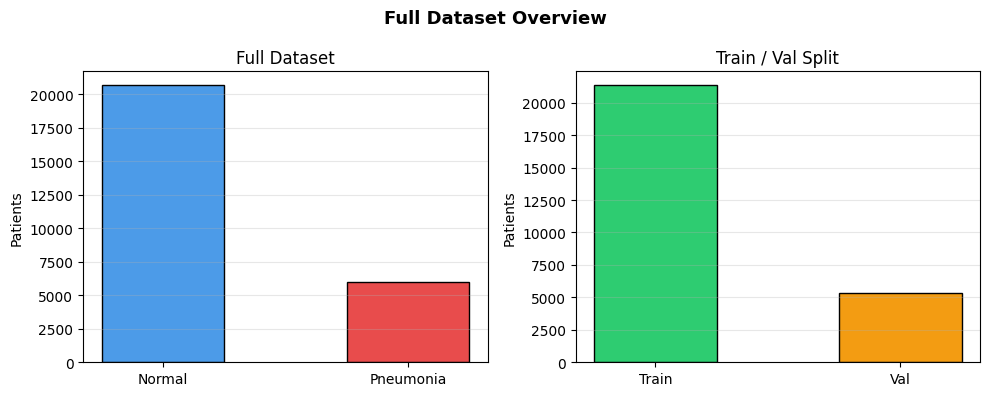

✅ Plot saved → dataset_distribution.png

  ✅ CHECKPOINT 2: Full Dataset Loaded & Split Ready
     Total patients : 26684
     Train          : 21347
     Val            : 5337
     Positive rate  : 22.5%


In [8]:
# ============================================================
# CODE 2: Load CSV + Full Dataset Train/Val Split
# ============================================================

# ── Load CSVs ─────────────────────────────────────────────────
df_labels   = pd.read_csv(TRAIN_LABELS)
df_detailed = pd.read_csv(TRAIN_DETAILED)

print(f"✅ CSVs loaded")
print(f"   train_labels rows    : {len(df_labels)}")
print(f"   detailed_class rows  : {len(df_detailed)}")

# ── Merge ─────────────────────────────────────────────────────
df = pd.merge(df_labels,
              df_detailed[["patientId", "class"]],
              on="patientId", how="left")
df = df.drop_duplicates()

# ── Separate positive / negative ──────────────────────────────
df_positive = df[df["Target"] == 1].copy()
df_negative = df[df["Target"] == 0].drop_duplicates(subset="patientId").copy()

# Scale bbox coords 1024 → 512
for col in ["x", "y", "width", "height"]:
    df_positive[f"{col}_512"] = df_positive[col] * (IMG_SIZE / 1024.0)

# Compute bbox centres and area (needed for synthetic bbox sampling)
df_positive["cx_512"] = df_positive["x_512"] + df_positive["width_512"]  / 2
df_positive["cy_512"] = df_positive["y_512"]  + df_positive["height_512"] / 2
df_positive["area_512"] = df_positive["width_512"] * df_positive["height_512"]

# One row per patient for splitting
df_pos_unique = df_positive.drop_duplicates(subset="patientId")[["patientId"]].copy()
df_pos_unique["label"] = 1
df_neg_unique = df_negative[["patientId"]].copy()
df_neg_unique["label"] = 0

df_all = pd.concat([df_pos_unique, df_neg_unique], ignore_index=True)

print(f"\n✅ Full dataset")
print(f"   Positive patients : {len(df_pos_unique)}")
print(f"   Negative patients : {len(df_neg_unique)}")
print(f"   Total patients    : {len(df_all)}")

# ── Stratified train / val split (80/20) ──────────────────────
train_pids_list, val_pids_list = train_test_split(
    df_all["patientId"].values,
    test_size    = 0.2,
    stratify     = df_all["label"].values,
    random_state = SEED
)

train_pids = set(train_pids_list)
val_pids   = set(val_pids_list)

print(f"\n✅ Train/Val split")
print(f"   Train : {len(train_pids)} patients")
print(f"   Val   : {len(val_pids)} patients")

# Verify stratification
train_sub = df_all[df_all["patientId"].isin(train_pids)]
val_sub   = df_all[df_all["patientId"].isin(val_pids)]
print(f"\n   Train pneumonia rate : {train_sub['label'].mean()*100:.1f}%")
print(f"   Val   pneumonia rate : {val_sub['label'].mean()*100:.1f}%")
print(f"   ✅ Stratification verified")

# ── Save for use in later codes ───────────────────────────────
df_positive.to_csv(OUTPUT_DIR / "df_positive_full.csv", index=False)
pd.Series(list(train_pids)).to_csv(OUTPUT_DIR / "train_pids.csv",
                                    index=False, header=["patientId"])
pd.Series(list(val_pids)).to_csv(OUTPUT_DIR / "val_pids.csv",
                                  index=False, header=["patientId"])

print(f"\n✅ Files saved")
print(f"   df_positive_full.csv")
print(f"   train_pids.csv")
print(f"   val_pids.csv")

# ── Quick class distribution plot ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Full Dataset Overview", fontsize=13, fontweight="bold")

# Full dataset distribution
axes[0].bar(["Normal", "Pneumonia"],
            [len(df_neg_unique), len(df_pos_unique)],
            color=["#4C9BE8", "#E84C4C"], edgecolor="black", width=0.5)
axes[0].set_title("Full Dataset")
axes[0].set_ylabel("Patients")
axes[0].grid(axis="y", alpha=0.3)

# Train vs Val
axes[1].bar(["Train", "Val"],
            [len(train_pids), len(val_pids)],
            color=["#2ECC71", "#F39C12"], edgecolor="black", width=0.5)
axes[1].set_title("Train / Val Split")
axes[1].set_ylabel("Patients")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved → dataset_distribution.png")

# ── CHECKPOINT 2 COMPLETE ─────────────────────────────────────
print("\n" + "="*50)
print("  ✅ CHECKPOINT 2: Full Dataset Loaded & Split Ready")
print(f"     Total patients : {len(df_all)}")
print(f"     Train          : {len(train_pids)}")
print(f"     Val            : {len(val_pids)}")
print(f"     Positive rate  : {df_all['label'].mean()*100:.1f}%")
print("="*50)

✅ Patient IDs loaded
   Train : 21347
   Val   : 5337
   Total : 26684

🔄 Converting 26684 DICOMs → PNG (full dataset)...
   Full dataset conversion — may take 60–90 minutes



DICOM → PNG:   0%|          | 0/26684 [00:00<?, ?it/s]


✅ Conversion complete
   Successful : 26684
   Failed     : 0

✅ Total PNGs in output : 26684


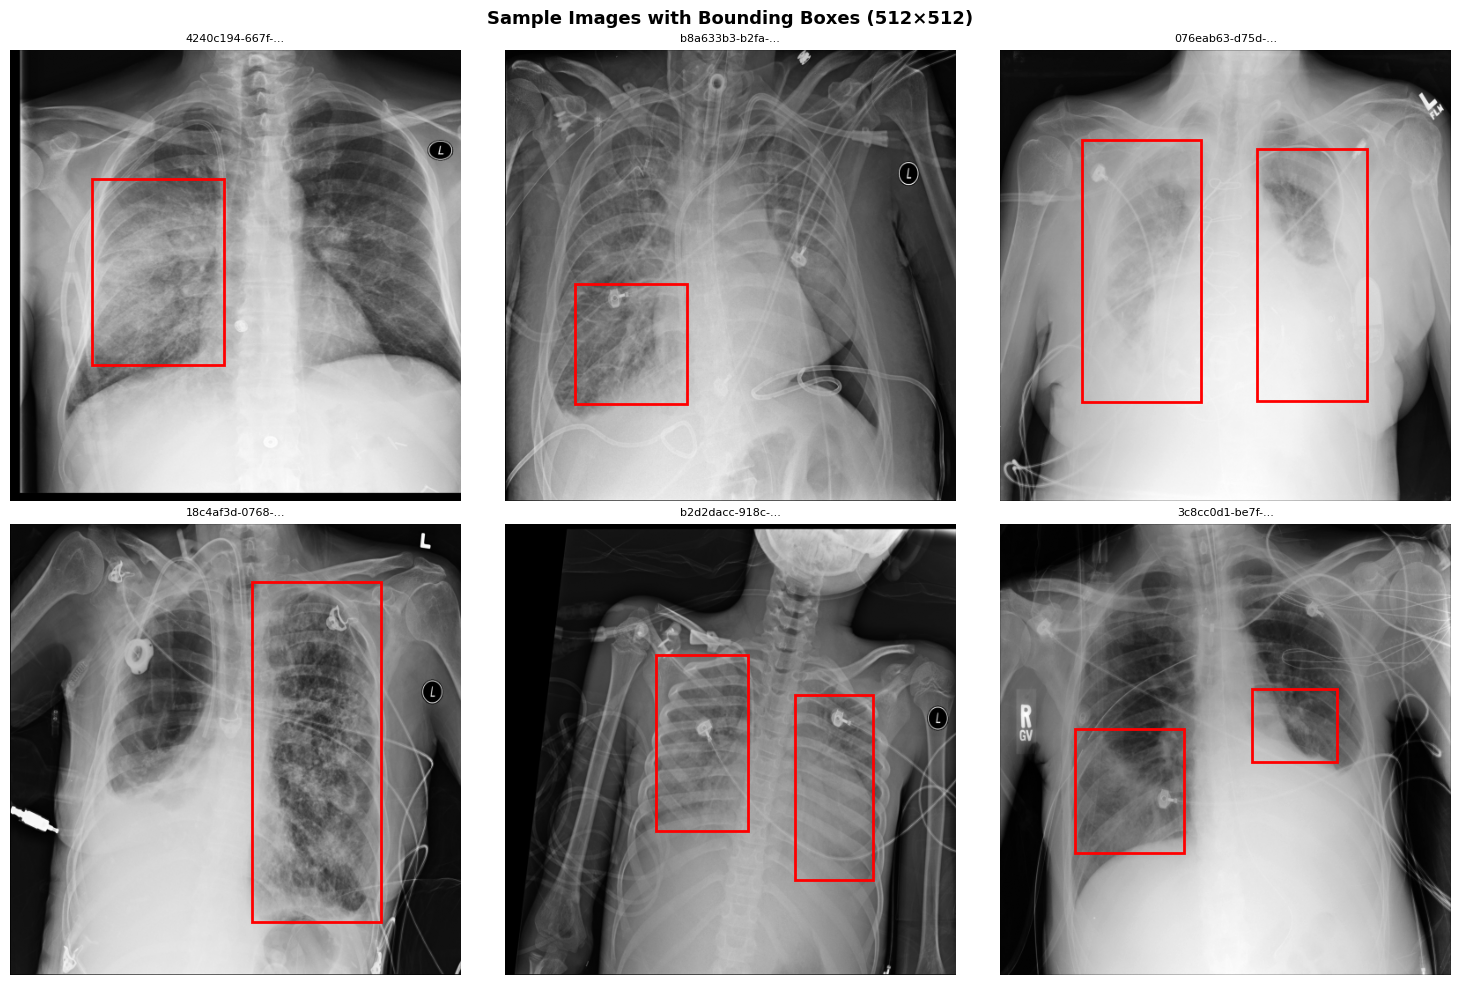

✅ Sample plot saved → sample_images.png

🔄 Computing pixel statistics on 100 random images...
   Mean pixel intensity : 128.30 ± 22.41
   Mean pixel std dev   : 58.90 ± 10.30
   ✅ Values look normal for CXR (expected mean ~100–150)

⚠️  REMINDER: Click 'Save Version' → Quick Save now!
   PNGs take 60–90 min to regenerate if session restarts

  ✅ CHECKPOINT 3: DICOM → PNG Conversion Done
     PNGs converted : 26684
     Failed         : 0
     Output dir     : /kaggle/working/rsna_project/png_images


In [9]:
# ============================================================
# CODE 3: DICOM → PNG Conversion (Full Dataset, 512×512)
# ============================================================

import gc
from tqdm.notebook import tqdm

# ── Load split patient IDs ────────────────────────────────────
train_pids = set(pd.read_csv(OUTPUT_DIR / "train_pids.csv")["patientId"].tolist())
val_pids   = set(pd.read_csv(OUTPUT_DIR / "val_pids.csv")["patientId"].tolist())
all_pids   = train_pids | val_pids

print(f"✅ Patient IDs loaded")
print(f"   Train : {len(train_pids)}")
print(f"   Val   : {len(val_pids)}")
print(f"   Total : {len(all_pids)}")

# ── DICOM → PNG function ──────────────────────────────────────
def dicom_to_png(patient_id, src_dir, dst_dir, size=IMG_SIZE):
    dcm_path = src_dir / f"{patient_id}.dcm"
    png_path  = dst_dir / f"{patient_id}.png"

    if png_path.exists():
        return patient_id, True, "already_exists"

    try:
        dcm   = pydicom.dcmread(str(dcm_path))
        pixel = dcm.pixel_array.astype(np.float32)

        # Normalize to [0, 255]
        p_min, p_max = pixel.min(), pixel.max()
        if p_max > p_min:
            pixel = (pixel - p_min) / (p_max - p_min) * 255.0
        else:
            pixel = np.zeros_like(pixel)
        pixel = pixel.astype(np.uint8)

        # Handle MONOCHROME1 (inverted)
        if hasattr(dcm, "PhotometricInterpretation"):
            if dcm.PhotometricInterpretation == "MONOCHROME1":
                pixel = 255 - pixel

        # Resize to 512×512
        pixel_resized = cv2.resize(pixel, (size, size),
                                   interpolation=cv2.INTER_AREA)

        # Save as grayscale PNG
        Image.fromarray(pixel_resized, mode="L").save(str(png_path))
        return patient_id, True, None

    except Exception as e:
        return patient_id, False, str(e)

# ── Convert full dataset ──────────────────────────────────────
print(f"\n🔄 Converting {len(all_pids)} DICOMs → PNG (full dataset)...")
print(f"   Full dataset conversion — may take 60–90 minutes\n")

success, failed = 0, []

for pid in tqdm(all_pids, desc="DICOM → PNG"):
    _, ok, msg = dicom_to_png(pid, TRAIN_IMG_DIR, PNG_DIR)
    if ok:
        success += 1
    else:
        failed.append((pid, msg))

gc.collect()

print(f"\n✅ Conversion complete")
print(f"   Successful : {success}")
print(f"   Failed     : {len(failed)}")
if failed:
    print(f"   ⚠️  First 5 failures:")
    for pid, err in failed[:5]:
        print(f"      {pid} → {err}")

# ── Verify PNG output ─────────────────────────────────────────
png_files = list(PNG_DIR.glob("*.png"))
print(f"\n✅ Total PNGs in output : {len(png_files)}")

# ── Visual sanity check ───────────────────────────────────────
df_positive = pd.read_csv(OUTPUT_DIR / "df_positive_full.csv")

# Get positive patients that are in train split
subset_pos_pids = [p for p in list(train_pids)
                   if p in df_positive["patientId"].values][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
fig.suptitle("Sample Images with Bounding Boxes (512×512)",
             fontsize=13, fontweight="bold")

for i, pid in enumerate(subset_pos_pids):
    png_path = PNG_DIR / f"{pid}.png"
    if not png_path.exists():
        continue

    img  = np.array(Image.open(png_path))
    rows = df_positive[df_positive["patientId"] == pid]

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"{pid[:14]}...", fontsize=8)
    axes[i].axis("off")

    for _, row in rows.iterrows():
        rect = patches.Rectangle(
            (row["x_512"], row["y_512"]),
            row["width_512"], row["height_512"],
            linewidth=2, edgecolor="red", facecolor="none"
        )
        axes[i].add_patch(rect)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample plot saved → sample_images.png")

# ── Quick pixel stats on 100 random images ────────────────────
print("\n🔄 Computing pixel statistics on 100 random images...")
sample_pids = random.sample(list(all_pids), min(100, len(all_pids)))
means, stds = [], []

for pid in sample_pids:
    p = PNG_DIR / f"{pid}.png"
    if p.exists():
        arr = np.array(Image.open(p), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())

print(f"   Mean pixel intensity : {np.mean(means):.2f} ± {np.std(means):.2f}")
print(f"   Mean pixel std dev   : {np.mean(stds):.2f} ± {np.std(stds):.2f}")
print(f"   ✅ Values look normal for CXR (expected mean ~100–150)")

# ── Save version reminder ─────────────────────────────────────
print("\n⚠️  REMINDER: Click 'Save Version' → Quick Save now!")
print("   PNGs take 60–90 min to regenerate if session restarts")

# ── CHECKPOINT 3 COMPLETE ─────────────────────────────────────
print("\n" + "="*50)
print("  ✅ CHECKPOINT 3: DICOM → PNG Conversion Done")
print(f"     PNGs converted : {success}")
print(f"     Failed         : {len(failed)}")
print(f"     Output dir     : {PNG_DIR}")
print("="*50)

In [10]:
# ============================================================
# CODE 4: YOLO Label Generation + Split A Directory Setup
# ============================================================

import shutil

# ── Load data ─────────────────────────────────────────────────
df_positive = pd.read_csv(OUTPUT_DIR / "df_positive_full.csv")
train_pids  = set(pd.read_csv(OUTPUT_DIR / "train_pids.csv")["patientId"].tolist())
val_pids    = set(pd.read_csv(OUTPUT_DIR / "val_pids.csv")["patientId"].tolist())

print(f"✅ Data loaded")
print(f"   Train PIDs : {len(train_pids)}")
print(f"   Val   PIDs : {len(val_pids)}")

# ── YOLO directory structure for Split A ──────────────────────
YOLO_A = SPLIT_DIR / "split_A"

for split in ["train", "val"]:
    (YOLO_A / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_A / "labels" / split).mkdir(parents=True, exist_ok=True)

print(f"\n✅ Split A directories created")
print(f"   {YOLO_A}")

# ── Helper: bbox → YOLO normalized format ─────────────────────
def to_yolo_format(x, y, w, h, img_size=IMG_SIZE):
    cx = (x + w / 2) / img_size
    cy = (y + h / 2) / img_size
    nw =  w / img_size
    nh =  h / img_size
    cx = min(max(cx, 0.0), 1.0)
    cy = min(max(cy, 0.0), 1.0)
    nw = min(max(nw, 0.0), 1.0)
    nh = min(max(nh, 0.0), 1.0)
    return cx, cy, nw, nh

# ── Helper: write YOLO label file ─────────────────────────────
def write_yolo_label(patient_id, df_pos, label_dir):
    label_path = label_dir / f"{patient_id}.txt"
    rows = df_pos[df_pos["patientId"] == patient_id]
    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            cx, cy, nw, nh = to_yolo_format(
                row["x_512"], row["y_512"],
                row["width_512"], row["height_512"]
            )
            f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# ── Copy PNGs + write labels ───────────────────────────────────
print("\n🔄 Setting up Split A images and labels...")

train_count, val_count = 0, 0
missing = []

for pid in tqdm(train_pids, desc="Train"):
    src = PNG_DIR / f"{pid}.png"
    dst = YOLO_A / "images" / "train" / f"{pid}.png"
    if src.exists():
        if not dst.exists():
            shutil.copy2(str(src), str(dst))
        write_yolo_label(pid, df_positive,
                         YOLO_A / "labels" / "train")
        train_count += 1
    else:
        missing.append(pid)

for pid in tqdm(val_pids, desc="Val"):
    src = PNG_DIR / f"{pid}.png"
    dst = YOLO_A / "images" / "val" / f"{pid}.png"
    if src.exists():
        if not dst.exists():
            shutil.copy2(str(src), str(dst))
        write_yolo_label(pid, df_positive,
                         YOLO_A / "labels" / "val")
        val_count += 1
    else:
        missing.append(pid)

print(f"\n✅ Split A setup complete")
print(f"   Train images : {train_count}")
print(f"   Val   images : {val_count}")
if missing:
    print(f"   ⚠️  Missing PNGs : {len(missing)}")

# ── Write dataset YAML ────────────────────────────────────────
yaml_content = f"""# RSNA Pneumonia — Split A (Real full dataset)
path  : {str(YOLO_A)}
train : images/train
val   : images/val

nc    : 1
names : ['pneumonia']
"""

yaml_path = YOLO_A / "dataset.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"\n✅ dataset.yaml saved → {yaml_path}")
print("\n── YAML contents ──")
print(yaml_content)

# ── Verify label files ────────────────────────────────────────
train_labels     = list((YOLO_A / "labels" / "train").glob("*.txt"))
val_labels       = list((YOLO_A / "labels" / "val").glob("*.txt"))
train_pos_labels = [f for f in train_labels if f.stat().st_size > 0]
val_pos_labels   = [f for f in val_labels   if f.stat().st_size > 0]

print(f"── Label verification ──")
print(f"   Train total    : {len(train_labels)}")
print(f"   Train positive : {len(train_pos_labels)}")
print(f"   Train negative : {len(train_labels) - len(train_pos_labels)}")
print(f"   Val   total    : {len(val_labels)}")
print(f"   Val   positive : {len(val_pos_labels)}")
print(f"   Val   negative : {len(val_labels) - len(val_pos_labels)}")

# ── Sanity check: read back 3 label files ─────────────────────
print(f"\n── Sample YOLO labels (3 positive) ──")
for lf in train_pos_labels[:3]:
    print(f"   {lf.name}:")
    with open(lf) as f:
        for line in f:
            print(f"      {line.strip()}")

# ── Save bbox distribution stats for synthetic sampling ───────
# These stats are used in Code 7 to sample realistic bbox locations
pos_train_pids = [f.stem for f in train_pos_labels]
df_pos_train   = df_positive[df_positive["patientId"].isin(pos_train_pids)]

bbox_stats = {
    "cx_mean"  : float(df_pos_train["cx_512"].mean()),
    "cx_std"   : float(df_pos_train["cx_512"].std()),
    "cy_mean"  : float(df_pos_train["cy_512"].mean()),
    "cy_std"   : float(df_pos_train["cy_512"].std()),
    "w_mean"   : float(df_pos_train["width_512"].mean()),
    "w_std"    : float(df_pos_train["width_512"].std()),
    "h_mean"   : float(df_pos_train["height_512"].mean()),
    "h_std"    : float(df_pos_train["height_512"].std()),
}

pd.DataFrame([bbox_stats]).to_csv(OUTPUT_DIR / "bbox_stats.csv", index=False)

print(f"\n✅ BBox stats saved → bbox_stats.csv")
print(f"   cx  : {bbox_stats['cx_mean']:.1f} ± {bbox_stats['cx_std']:.1f} px")
print(f"   cy  : {bbox_stats['cy_mean']:.1f} ± {bbox_stats['cy_std']:.1f} px")
print(f"   w   : {bbox_stats['w_mean']:.1f}  ± {bbox_stats['w_std']:.1f}  px")
print(f"   h   : {bbox_stats['h_mean']:.1f}  ± {bbox_stats['h_std']:.1f}  px")

# ── Save version reminder ─────────────────────────────────────
print("\n⚠️  REMINDER: Click 'Save Version' → Quick Save now!")

# ── CHECKPOINT 4 COMPLETE ─────────────────────────────────────
print("\n" + "="*50)
print("  ✅ CHECKPOINT 4: Split A Ready for Training")
print(f"     Train images   : {train_count}")
print(f"     Val   images   : {val_count}")
print(f"     Train +ve      : {len(train_pos_labels)}")
print(f"     Val   +ve      : {len(val_pos_labels)}")
print(f"     YAML           : {yaml_path}")
print("="*50)

✅ Data loaded
   Train PIDs : 21347
   Val   PIDs : 5337

✅ Split A directories created
   /kaggle/working/rsna_project/splits/split_A

🔄 Setting up Split A images and labels...


Train:   0%|          | 0/21347 [00:00<?, ?it/s]

Val:   0%|          | 0/5337 [00:00<?, ?it/s]


✅ Split A setup complete
   Train images : 21347
   Val   images : 5337

✅ dataset.yaml saved → /kaggle/working/rsna_project/splits/split_A/dataset.yaml

── YAML contents ──
# RSNA Pneumonia — Split A (Real full dataset)
path  : /kaggle/working/rsna_project/splits/split_A
train : images/train
val   : images/val

nc    : 1
names : ['pneumonia']

── Label verification ──
   Train total    : 21347
   Train positive : 4810
   Train negative : 16537
   Val   total    : 5337
   Val   positive : 1202
   Val   negative : 4135

── Sample YOLO labels (3 positive) ──
   ad217b8d-1a8a-4347-871c-812febbde1e4.txt:
      0 0.250000 0.713867 0.281250 0.441406
      0 0.770996 0.565918 0.338867 0.426758
   d7131b83-ef4c-4a0a-b1a2-d09c163bda48.txt:
      0 0.201172 0.675293 0.195312 0.120117
   6aefeac2-d497-47c9-939d-5558d039ae1a.txt:
      0 0.584961 0.377930 0.199219 0.236328
      0 0.268066 0.336426 0.151367 0.211914

✅ BBox stats saved → bbox_stats.csv
   cx  : 251.7 ± 102.5 px
   cy  : 265.4 ± 5

✅ YAML verified
✅ Device : GPU → Tesla T4

   Train : 21347 images
   Val   : 5337 images
   Expected time : ~2–4 hrs on T4

🔄 Resuming from : /kaggle/working/rsna_project/rsna_yolo/split_A_real_only/weights/last.pt
WARNING ⚠️ model '/kaggle/working/rsna_project/rsna_yolo/split_A_real_only/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist

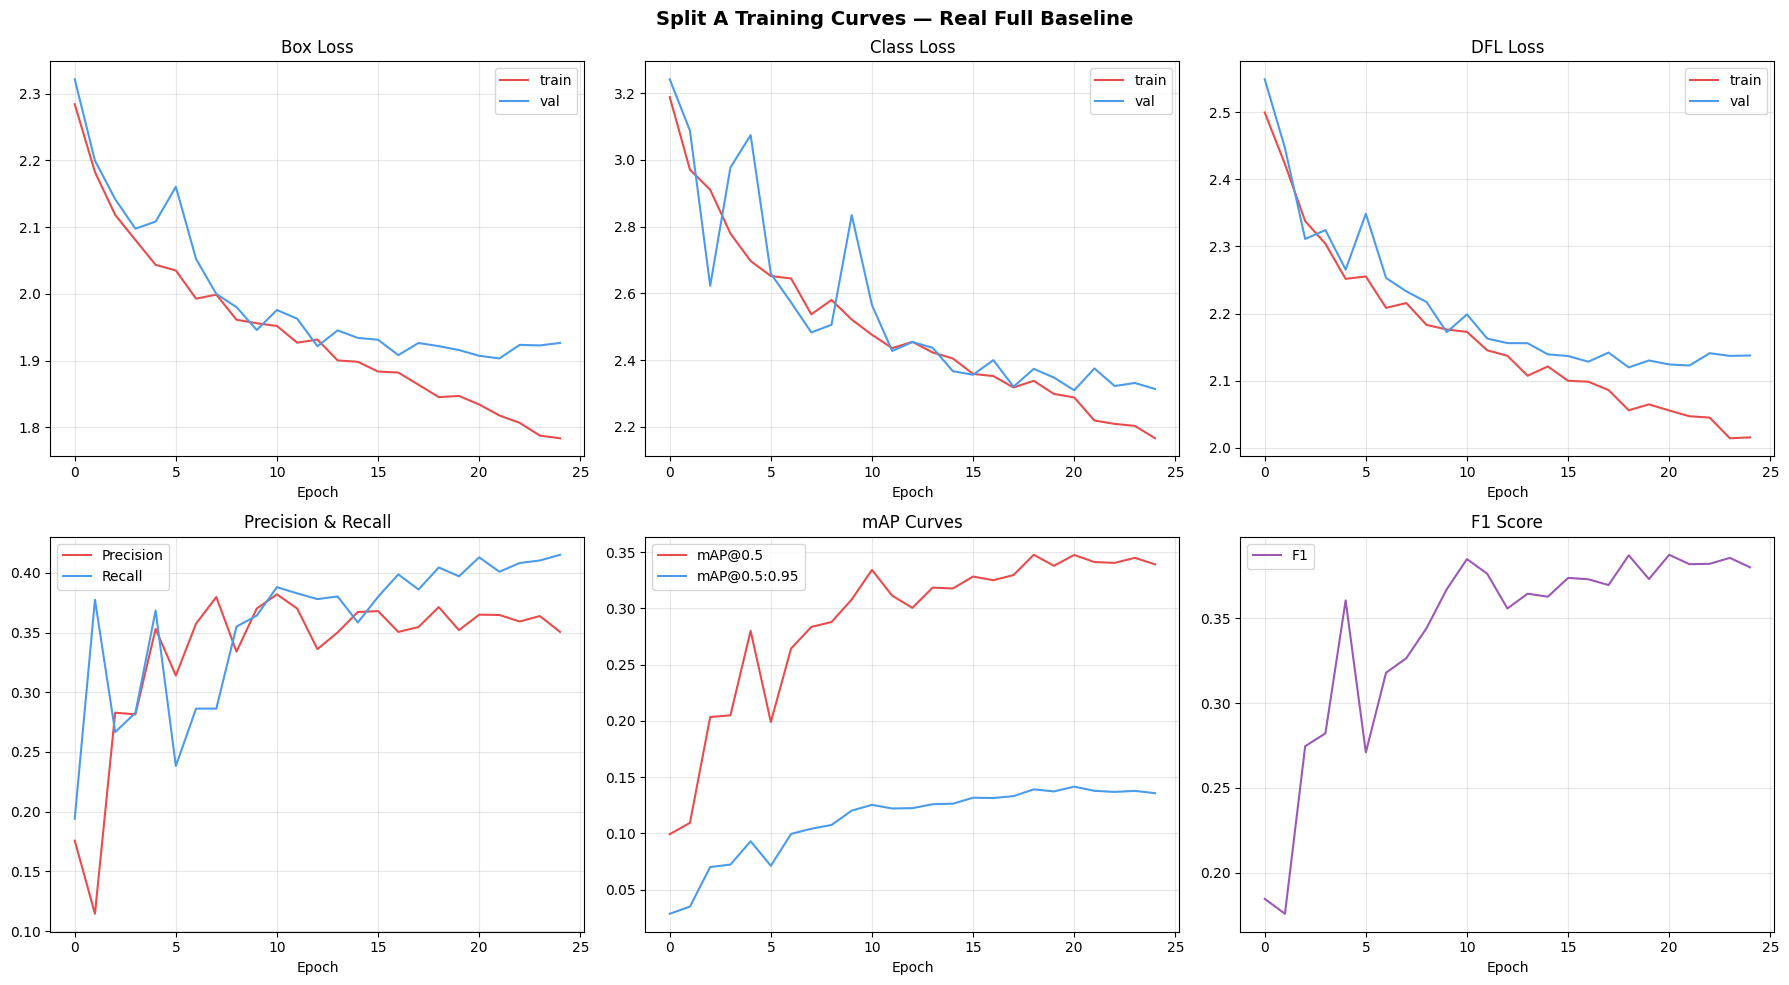

✅ Training curves saved → training_curves_split_A.png

✅ best.pt backed up → /kaggle/working/best_split_A.pt
⚠️  Click 'Save Version' → Quick Save RIGHT NOW to preserve weights!

  ✅ CHECKPOINT 5: Split A Training Complete
     mAP@0.5      : 0.3477  ← baseline to beat
     mAP@0.5:0.95 : 0.1417
     Recall       : 0.4104
     Precision    : 0.3645
     F1           : 0.3861
     Best weights : /kaggle/working/rsna_project/rsna_yolo/split_A_real_only/weights/best.pt

  ⚠️  SPLIT_A_BEST needed for BAS filter in Code 7


In [11]:
# ============================================================
# CODE 5: YOLOv8-m Training on Split A (Real Full Baseline)
# ============================================================

from ultralytics import YOLO

# ── Config ────────────────────────────────────────────────────
EPOCHS       = 25
IMG_SZ       = 512
BATCH_SIZE   = 16
PATIENCE     = 15
PROJECT_NAME = "rsna_yolo"
RUN_NAME_A   = "split_A_real_only"

# ── Paths ─────────────────────────────────────────────────────
YOLO_A       = SPLIT_DIR / "split_A"
yaml_path    = YOLO_A / "dataset.yaml"
SPLIT_A_BEST = OUTPUT_DIR / PROJECT_NAME / RUN_NAME_A / "weights" / "best.pt"
SPLIT_A_LAST = OUTPUT_DIR / PROJECT_NAME / RUN_NAME_A / "weights" / "last.pt"

assert yaml_path.exists(), f"❌ YAML not found: {yaml_path}"
print("✅ YAML verified")

# ── Verify GPU ────────────────────────────────────────────────
device = "0" if torch.cuda.is_available() else "cpu"
print(f"✅ Device : {'GPU → ' + torch.cuda.get_device_name(0) if device == '0' else 'CPU ⚠️'}")

# ── Count images ──────────────────────────────────────────────
train_imgs = list((YOLO_A / "images" / "train").glob("*.png"))
val_imgs   = list((YOLO_A / "images" / "val").glob("*.png"))
print(f"\n   Train : {len(train_imgs)} images")
print(f"   Val   : {len(val_imgs)} images")
print(f"   Expected time : ~2–4 hrs on T4\n")

# ── Smart load: resume if checkpoint exists, else fresh ───────
if SPLIT_A_LAST.exists():
    print(f"🔄 Resuming from : {SPLIT_A_LAST}")
    model_A  = YOLO(str(SPLIT_A_LAST))
    results_A = model_A.train(resume=True)
else:
    print("🔄 No checkpoint found — starting fresh training...")
    model_A   = YOLO("yolov8m.pt")
    results_A = model_A.train(
        data         = str(yaml_path),
        epochs       = EPOCHS,
        imgsz        = IMG_SZ,
        batch        = BATCH_SIZE,
        patience     = PATIENCE,
        device       = device,
        project      = str(OUTPUT_DIR / PROJECT_NAME),
        name         = RUN_NAME_A,
        exist_ok     = True,

        # Optimizer
        optimizer    = "AdamW",
        lr0          = 1e-3,
        lrf          = 0.01,
        momentum     = 0.937,
        weight_decay = 5e-4,
        warmup_epochs= 3,

        # Augmentation
        hsv_h        = 0.0,
        hsv_s        = 0.0,
        hsv_v        = 0.3,
        fliplr       = 0.5,
        flipud       = 0.0,
        translate    = 0.1,
        scale        = 0.3,
        mosaic       = 0.0,
        mixup        = 0.0,

        # Misc
        val          = True,
        save         = True,
        save_period  = 5,
        plots        = True,
        verbose      = True,
        seed         = SEED,
        workers      = 2,
    )

print("\n✅ Split A training complete")

# ── Evaluate best model ───────────────────────────────────────
assert SPLIT_A_BEST.exists(), "❌ best.pt not found"

print("\n🔄 Evaluating best checkpoint...")
model_A_best  = YOLO(str(SPLIT_A_BEST))
val_results_A = model_A_best.val(
    data      = str(yaml_path),
    imgsz     = IMG_SZ,
    batch     = BATCH_SIZE,
    device    = device,
    verbose   = True,
    plots     = True,
    save_json = True,
)

# ── Extract metrics ───────────────────────────────────────────
map50     = float(val_results_A.box.map50)
map5095   = float(val_results_A.box.map)
recall    = float(val_results_A.box.mr)
precision = float(val_results_A.box.mp)
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print("\n" + "─"*45)
print("  Split A — Results (Real Full Baseline)")
print("─"*45)
print(f"  mAP@0.5       : {map50:.4f}  ← baseline to beat")
print(f"  mAP@0.5:0.95  : {map5095:.4f}")
print(f"  Recall        : {recall:.4f}")
print(f"  Precision     : {precision:.4f}")
print(f"  F1            : {f1:.4f}")
print("─"*45)

# ── Save metrics ──────────────────────────────────────────────
metrics_A = {
    "split"    : "A_real_only",
    "mAP50"    : round(map50,    4),
    "mAP5095"  : round(map5095,  4),
    "recall"   : round(recall,   4),
    "precision": round(precision,4),
    "F1"       : round(f1,       4),
}
pd.DataFrame([metrics_A]).to_csv(OUTPUT_DIR / "metrics_split_A.csv", index=False)
print(f"\n✅ Metrics saved → metrics_split_A.csv")

# ── Plot training curves ──────────────────────────────────────
results_csv = OUTPUT_DIR / PROJECT_NAME / RUN_NAME_A / "results.csv"

if results_csv.exists():
    res_df = pd.read_csv(results_csv)
    res_df.columns = res_df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Split A Training Curves — Real Full Baseline",
                 fontsize=14, fontweight="bold")

    pairs = [
        ("train/box_loss", "val/box_loss",  "Box Loss",    axes[0,0]),
        ("train/cls_loss", "val/cls_loss",  "Class Loss",  axes[0,1]),
        ("train/dfl_loss", "val/dfl_loss",  "DFL Loss",    axes[0,2]),
    ]
    for tc, vc, title, ax in pairs:
        if tc in res_df.columns:
            ax.plot(res_df[tc], label="train", color="#E84C4C")
        if vc in res_df.columns:
            ax.plot(res_df[vc], label="val",   color="#4C9BE8")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    if "metrics/precision(B)" in res_df.columns:
        axes[1,0].plot(res_df["metrics/precision(B)"],
                       label="Precision", color="#E84C4C")
        axes[1,0].plot(res_df["metrics/recall(B)"],
                       label="Recall",    color="#4C9BE8")
        axes[1,0].set_title("Precision & Recall")
        axes[1,0].set_xlabel("Epoch")
        axes[1,0].legend()
        axes[1,0].grid(alpha=0.3)

    if "metrics/mAP50(B)" in res_df.columns:
        axes[1,1].plot(res_df["metrics/mAP50(B)"],
                       label="mAP@0.5",     color="#E84C4C")
    if "metrics/mAP50-95(B)" in res_df.columns:
        axes[1,1].plot(res_df["metrics/mAP50-95(B)"],
                       label="mAP@0.5:0.95",color="#4C9BE8")
    axes[1,1].set_title("mAP Curves")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)

    # F1 approximation
    if all(c in res_df.columns for c in
           ["metrics/precision(B)", "metrics/recall(B)"]):
        p = res_df["metrics/precision(B)"]
        r = res_df["metrics/recall(B)"]
        f = 2 * p * r / (p + r + 1e-8)
        axes[1,2].plot(f, label="F1", color="#9B59B6")
        axes[1,2].set_title("F1 Score")
        axes[1,2].set_xlabel("Epoch")
        axes[1,2].legend()
        axes[1,2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves_split_A.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Training curves saved → training_curves_split_A.png")

# ── Immediately backup best.pt ────────────────────────────────
import shutil
backup_path = "/kaggle/working/best_split_A.pt"
shutil.copy2(str(SPLIT_A_BEST), backup_path)
print(f"\n✅ best.pt backed up → {backup_path}")
print("⚠️  Click 'Save Version' → Quick Save RIGHT NOW to preserve weights!")

# ── CHECKPOINT 5 COMPLETE ─────────────────────────────────────
print("\n" + "="*55)
print("  ✅ CHECKPOINT 5: Split A Training Complete")
print(f"     mAP@0.5      : {map50:.4f}  ← baseline to beat")
print(f"     mAP@0.5:0.95 : {map5095:.4f}")
print(f"     Recall       : {recall:.4f}")
print(f"     Precision    : {precision:.4f}")
print(f"     F1           : {f1:.4f}")
print(f"     Best weights : {SPLIT_A_BEST}")
print("="*55)
print("\n  ⚠️  SPLIT_A_BEST needed for BAS filter in Code 7")

In [12]:
# ============================================================
# CODE 7: Traditional Augmentation → Split B
# ============================================================

import cv2, shutil
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import random, json

# ── Config ────────────────────────────────────────────────────
N_AUG_PER_IMAGE = 4      # 4803 pos × 4 = ~19212 augmented → balances 16544 negatives

print("✅ Traditional Augmentation — Split B")
print(f"   Method : flip + rotation + crop + brightness")
print(f"   Source : {len([p for p in train_pids if p in df_positive['patientId'].values])} positive train patients")

# ── Load data ─────────────────────────────────────────────────
df_positive = pd.read_csv(OUTPUT_DIR / "df_positive_full.csv")
train_pids  = set(pd.read_csv(OUTPUT_DIR / "train_pids.csv")["patientId"].tolist())
val_pids    = set(pd.read_csv(OUTPUT_DIR / "val_pids.csv")["patientId"].tolist())

pos_train_pids = [p for p in train_pids
                  if p in df_positive["patientId"].values]

print(f"   Positive train patients : {len(pos_train_pids)}")
print(f"   Augmented images target : {len(pos_train_pids) * N_AUG_PER_IMAGE}")

# ── Augmentation dir ──────────────────────────────────────────
AUG_DIR = OUTPUT_DIR / "augmented_images"
if AUG_DIR.exists():
    shutil.rmtree(str(AUG_DIR))
AUG_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper: YOLO format ───────────────────────────────────────
def to_yolo(x, y, w, h, img_size=IMG_SIZE):
    cx = (x + w/2) / img_size
    cy = (y + h/2) / img_size
    nw =  w / img_size
    nh =  h / img_size
    return (min(max(cx,0),1), min(max(cy,0),1),
            min(max(nw,0),1), min(max(nh,0),1))

# ── Augmentation functions ────────────────────────────────────
def aug_hflip(img, bbox):
    x, y, w, h = bbox
    img  = cv2.flip(img, 1)
    x    = IMG_SIZE - x - w
    return img, (max(x,0), y, w, h)

def aug_rotate(img, bbox, angle_range=15):
    x, y, w, h = bbox
    angle = random.uniform(-angle_range, angle_range)
    cx_i, cy_i = IMG_SIZE//2, IMG_SIZE//2
    M    = cv2.getRotationMatrix2D((cx_i, cy_i), angle, 1.0)
    img  = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE),
                          borderMode=cv2.BORDER_REFLECT)
    bcx  = x + w/2 - cx_i
    bcy  = y + h/2 - cy_i
    rad  = np.deg2rad(-angle)
    ncx  = bcx*np.cos(rad) - bcy*np.sin(rad) + cx_i
    ncy  = bcx*np.sin(rad) + bcy*np.cos(rad) + cy_i
    nx   = np.clip(ncx - w/2, 0, IMG_SIZE - w)
    ny   = np.clip(ncy - h/2, 0, IMG_SIZE - h)
    return img, (float(nx), float(ny), w, h)

def aug_brightness(img, factor_range=(0.6, 1.5)):
    factor = random.uniform(*factor_range)
    out    = np.clip(img.astype(np.float32) * factor, 0, 255)
    return out.astype(np.uint8)

def aug_crop_pad(img, bbox, shift=20):
    x, y, w, h = bbox
    sx = random.randint(-shift, shift)
    sy = random.randint(-shift, shift)
    M  = np.float32([[1,0,sx],[0,1,sy]])
    img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE),
                         borderMode=cv2.BORDER_REFLECT)
    nx = np.clip(x + sx, 0, IMG_SIZE - w)
    ny = np.clip(y + sy, 0, IMG_SIZE - h)
    return img, (float(nx), float(ny), w, h)

def augment(img, bbox, aug_id):
    """Apply different combo per aug_id for diversity."""
    if aug_id % 4 == 0:
        img, bbox = aug_hflip(img, bbox)
        img, bbox = aug_rotate(img, bbox, angle_range=10)
        img       = aug_brightness(img, (0.7, 1.3))
    elif aug_id % 4 == 1:
        img, bbox = aug_crop_pad(img, bbox, shift=25)
        img, bbox = aug_rotate(img, bbox, angle_range=15)
        img       = aug_brightness(img, (0.6, 1.5))
    elif aug_id % 4 == 2:
        img, bbox = aug_hflip(img, bbox)
        img, bbox = aug_crop_pad(img, bbox, shift=15)
        img       = aug_brightness(img, (0.8, 1.4))
    else:
        img, bbox = aug_rotate(img, bbox, angle_range=12)
        img       = aug_brightness(img, (0.65, 1.45))
    return img, bbox

# ── Generate augmented images ─────────────────────────────────
aug_records = []
print(f"\n🔄 Generating augmented images...")

for pid in tqdm(pos_train_pids, desc="Augmenting"):
    src = PNG_DIR / f"{pid}.png"
    if not src.exists():
        continue

    img  = np.array(Image.open(src).convert("L"))
    rows = df_positive[df_positive["patientId"] == pid]
    row  = rows.iloc[0]
    bbox = (row["x_512"], row["y_512"],
            row["width_512"], row["height_512"])

    for aug_id in range(N_AUG_PER_IMAGE):
        try:
            aug_img, aug_bbox = augment(img.copy(), bbox, aug_id)
            img_name = f"aug_{pid}_{aug_id}.png"
            img_path = AUG_DIR / img_name
            Image.fromarray(aug_img, mode="L").save(str(img_path))

            aug_records.append({
                "img_name" : img_name,
                "img_path" : str(img_path),
                "source_pid": pid,
                "x"        : round(float(aug_bbox[0]), 2),
                "y"        : round(float(aug_bbox[1]), 2),
                "width"    : round(float(aug_bbox[2]), 2),
                "height"   : round(float(aug_bbox[3]), 2),
            })
        except Exception as e:
            continue

df_aug = pd.DataFrame(aug_records)
df_aug.to_csv(OUTPUT_DIR / "augmented_records.csv", index=False)
print(f"✅ Augmented images : {len(df_aug)}")

# ── Build Split B YOLO structure ──────────────────────────────
print(f"\n🔄 Building Split B directory...")
YOLO_B = SPLIT_DIR / "split_B"
for split in ["train","val"]:
    (YOLO_B/"images"/split).mkdir(parents=True, exist_ok=True)
    (YOLO_B/"labels"/split).mkdir(parents=True, exist_ok=True)

# Real train images
for pid in tqdm(train_pids, desc="Real train"):
    src = PNG_DIR / f"{pid}.png"
    dst = YOLO_B / "images" / "train" / f"{pid}.png"
    if src.exists():
        if not dst.exists():
            shutil.copy2(str(src), str(dst))
        lpath = YOLO_B / "labels" / "train" / f"{pid}.txt"
        rows  = df_positive[df_positive["patientId"] == pid]
        with open(lpath, "w") as f:
            for _, row in rows.iterrows():
                cx,cy,nw,nh = to_yolo(
                    row["x_512"], row["y_512"],
                    row["width_512"], row["height_512"])
                f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# Augmented train images
for _, rec in tqdm(df_aug.iterrows(),
                   total=len(df_aug), desc="Aug train"):
    src = Path(rec["img_path"])
    dst = YOLO_B / "images" / "train" / rec["img_name"]
    if src.exists():
        if not dst.exists():
            shutil.copy2(str(src), str(dst))
        lpath = YOLO_B / "labels" / "train" / \
                f"{Path(rec['img_name']).stem}.txt"
        cx,cy,nw,nh = to_yolo(
            rec["x"], rec["y"], rec["width"], rec["height"])
        with open(lpath, "w") as f:
            f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# Val — real only
for pid in tqdm(val_pids, desc="Val"):
    src = PNG_DIR / f"{pid}.png"
    dst = YOLO_B / "images" / "val" / f"{pid}.png"
    if src.exists():
        if not dst.exists():
            shutil.copy2(str(src), str(dst))
        lpath = YOLO_B / "labels" / "val" / f"{pid}.txt"
        rows  = df_positive[df_positive["patientId"] == pid]
        with open(lpath, "w") as f:
            for _, row in rows.iterrows():
                cx,cy,nw,nh = to_yolo(
                    row["x_512"], row["y_512"],
                    row["width_512"], row["height_512"])
                f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# YAML
yaml_B = f"""# Split B — Traditional Augmentation (Full Dataset)
path  : {str(YOLO_B)}
train : images/train
val   : images/val
nc    : 1
names : ['pneumonia']
"""
with open(YOLO_B/"dataset.yaml","w") as f:
    f.write(yaml_B)

b_train = list((YOLO_B/"images"/"train").glob("*.png"))
b_val   = list((YOLO_B/"images"/"val").glob("*.png"))
print(f"\n✅ Split B ready")
print(f"   Train : {len(b_train)} ({len(train_pids)} real + {len(df_aug)} augmented)")
print(f"   Val   : {len(b_val)} real only")

# ── Train YOLO on Split B ─────────────────────────────────────
from ultralytics import YOLO
import torch

device    = "0" if torch.cuda.is_available() else "cpu"
yaml_path = YOLO_B / "dataset.yaml"
RUN_B     = "split_B_trad_aug"
last_B    = OUTPUT_DIR/"rsna_yolo"/RUN_B/"weights"/"last.pt"
best_B    = OUTPUT_DIR/"rsna_yolo"/RUN_B/"weights"/"best.pt"

print(f"\n🔄 Training Split B YOLOv8 (~3–5 hrs on T4)...")

if last_B.exists():
    model = YOLO(str(last_B))
    model.train(resume=True)
else:
    model = YOLO("yolov8m.pt")
    model.train(
        data         = str(yaml_path),
        epochs       = 25,
        imgsz        = 512,
        batch        = 16,
        patience     = 15,
        device       = device,
        project      = str(OUTPUT_DIR/"rsna_yolo"),
        name         = RUN_B,
        exist_ok     = True,
        optimizer    = "AdamW",
        lr0          = 1e-3,
        lrf          = 0.01,
        momentum     = 0.937,
        weight_decay = 5e-4,
        warmup_epochs= 3,
        hsv_h        = 0.0,
        hsv_s        = 0.0,
        hsv_v        = 0.3,
        fliplr       = 0.5,
        flipud       = 0.0,
        translate    = 0.1,
        scale        = 0.3,
        mosaic       = 0.0,
        mixup        = 0.0,
        val          = True,
        save         = True,
        save_period  = 5,
        plots        = True,
        verbose      = True,
        seed         = SEED,
        workers      = 2,
    )

# ── Evaluate ──────────────────────────────────────────────────
print("\n🔄 Evaluating Split B...")
model_B  = YOLO(str(best_B))
val_B    = model_B.val(
    data=str(yaml_path), imgsz=512,
    batch=16, device=device,
    verbose=False, plots=True)

map50_B  = float(val_B.box.map50)
map95_B  = float(val_B.box.map)
rec_B    = float(val_B.box.mr)
prec_B   = float(val_B.box.mp)
f1_B     = 2*prec_B*rec_B/(prec_B+rec_B+1e-8)

print(f"\n── Split B Results (Traditional Augmentation) ──")
print(f"   mAP@0.5      : {map50_B:.4f}")
print(f"   mAP@0.5:0.95 : {map95_B:.4f}")
print(f"   Recall       : {rec_B:.4f}")
print(f"   Precision    : {prec_B:.4f}")
print(f"   F1           : {f1_B:.4f}")

# Save metrics
pd.DataFrame([{
    "split"    : "B_trad_aug",
    "mAP50"    : round(map50_B, 4),
    "mAP5095"  : round(map95_B, 4),
    "recall"   : round(rec_B,   4),
    "precision": round(prec_B,  4),
    "F1"       : round(f1_B,    4),
}]).to_csv(OUTPUT_DIR/"metrics_split_B.csv", index=False)

shutil.copy2(str(best_B), "/kaggle/working/best_split_B.pt")
print(f"✅ Metrics saved + best_split_B.pt backed up")
print("⚠️  Quick Save NOW!")

# ── CHECKPOINT 7 COMPLETE ─────────────────────────────────────
print("\n" + "="*55)
print("  ✅ CHECKPOINT 7: Split B Complete")
print(f"     Augmented images : {len(df_aug)}")
print(f"     mAP@0.5          : {map50_B:.4f}")
print(f"     Recall           : {rec_B:.4f}")
print(f"     F1               : {f1_B:.4f}")
print("="*55)
print("\n  ➡️  Next: Code 8 — DCGAN for Split C")

✅ Traditional Augmentation — Split B
   Method : flip + rotation + crop + brightness
   Source : 4810 positive train patients
   Positive train patients : 4810
   Augmented images target : 19240

🔄 Generating augmented images...


Augmenting:   0%|          | 0/4810 [00:00<?, ?it/s]

✅ Augmented images : 19240

🔄 Building Split B directory...


Real train:   0%|          | 0/21347 [00:00<?, ?it/s]

Aug train:   0%|          | 0/19240 [00:00<?, ?it/s]

Val:   0%|          | 0/5337 [00:00<?, ?it/s]


✅ Split B ready
   Train : 40587 (21347 real + 19240 augmented)
   Val   : 5337 real only

🔄 Training Split B YOLOv8 (~3–5 hrs on T4)...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rsna_project/splits/split_B/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kag

In [13]:
# ============================================================
# CODE 8: DCGAN Training + Generation → Split C
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import shutil, json, gc, random

# ── Config ────────────────────────────────────────────────────
IMG_SZ       = 128    # DCGAN at 128×128 — quality + speed balance
LATENT_DIM   = 200    # larger latent = more diversity
EPOCHS       = 300    # enough for CXR structure
BATCH        = 32
LR_G         = 0.0002
LR_D         = 0.0001 # D slower than G — prevents mode collapse
BETA1        = 0.5
N_GENERATE   = N_SYNTHETIC   # 16544 — balances train positives vs negatives
GAN_DIR      = OUTPUT_DIR / "dcgan_model"
GAN_DIR.mkdir(parents=True, exist_ok=True)

print("✅ DCGAN Config")
print(f"   Image size  : {IMG_SZ}×{IMG_SZ} → upsample to 512")
print(f"   Latent dim  : {LATENT_DIM}")
print(f"   Epochs      : {EPOCHS}")
print(f"   Batch       : {BATCH}")
print(f"   LR G/D      : {LR_G}/{LR_D}")
print(f"   Generate    : {N_GENERATE} images (balance train set)")

# ── Load positive training images only ───────────────────────
df_positive = pd.read_csv(OUTPUT_DIR / "df_positive_full.csv")
train_pids  = set(pd.read_csv(OUTPUT_DIR / "train_pids.csv")["patientId"].tolist())
val_pids    = set(pd.read_csv(OUTPUT_DIR / "val_pids.csv")["patientId"].tolist())
bbox_stats  = pd.read_csv(OUTPUT_DIR / "bbox_stats.csv").iloc[0]

pos_train_pids = [p for p in train_pids
                  if p in df_positive["patientId"].values]
print(f"\n✅ Positive training images : {len(pos_train_pids)}")

# ── Dataset ───────────────────────────────────────────────────
class CXRDataset(Dataset):
    def __init__(self, pids, png_dir, size=IMG_SZ):
        self.paths = [png_dir/f"{p}.png" for p in pids
                      if (png_dir/f"{p}.png").exists()]
        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])
        print(f"   CXR Dataset : {len(self.paths)} images")

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("L"))

dataset = CXRDataset(pos_train_pids, PNG_DIR)
loader  = DataLoader(dataset, batch_size=BATCH,
                     shuffle=True, num_workers=2,
                     pin_memory=True, drop_last=True)

# ── Generator ─────────────────────────────────────────────────
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, z):
        return self.net(z.view(-1, LATENT_DIM, 1, 1))

# ── Discriminator ─────────────────────────────────────────────
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, True), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True), nn.Dropout2d(0.25),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, x): return self.net(x).view(-1)

# ── Init models ───────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator().to(device)
D = Discriminator().to(device)

g_params = sum(p.numel() for p in G.parameters())/1e6
d_params = sum(p.numel() for p in D.parameters())/1e6
print(f"\n✅ Generator     : {g_params:.1f}M params")
print(f"   Discriminator : {d_params:.1f}M params")
print(f"   VRAM          : {torch.cuda.memory_allocated()/1e9:.1f} GB")

# ── Loss + Optimizers ─────────────────────────────────────────
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# ── Fixed noise for progress visualization ────────────────────
fixed_noise = torch.randn(8, LATENT_DIM, device=device)

# ── Check for checkpoint ──────────────────────────────────────
ckpt_path   = GAN_DIR / "dcgan_checkpoint.pt"
start_epoch = 0
g_losses, d_losses = [], []

if ckpt_path.exists():
    print(f"\n🔄 Resuming DCGAN from checkpoint...")
    ckpt = torch.load(str(ckpt_path), map_location=device)
    G.load_state_dict(ckpt["G"])
    D.load_state_dict(ckpt["D"])
    opt_G.load_state_dict(ckpt["opt_G"])
    opt_D.load_state_dict(ckpt["opt_D"])
    start_epoch = ckpt["epoch"] + 1
    g_losses    = ckpt.get("g_losses", [])
    d_losses    = ckpt.get("d_losses", [])
    print(f"   Resuming from epoch {start_epoch}")
else:
    print(f"\n🔄 Starting fresh DCGAN training...")

# ── Label smoothing helper ────────────────────────────────────
def real_labels(n): return torch.FloatTensor(n).uniform_(0.85, 1.0).to(device)
def fake_labels(n): return torch.FloatTensor(n).uniform_(0.0, 0.15).to(device)

# ── Training loop ─────────────────────────────────────────────
print(f"\n🔄 Training DCGAN on {len(dataset)} pneumonia CXRs...")
print(f"   Epochs {start_epoch}→{EPOCHS} | "
      f"~{(EPOCHS-start_epoch)*len(loader)*0.05/60:.0f}–"
      f"{(EPOCHS-start_epoch)*len(loader)*0.08/60:.0f} min\n")

for epoch in tqdm(range(start_epoch, EPOCHS), desc="DCGAN Epochs"):
    g_epoch, d_epoch = 0.0, 0.0
    n_batches = 0

    for real_imgs in loader:
        real_imgs = real_imgs.to(device)
        bsz       = real_imgs.size(0)

        # ── Train Discriminator ──────────────────────────────
        D.zero_grad()
        out_real  = D(real_imgs)
        loss_real = criterion(out_real, real_labels(bsz))
        z         = torch.randn(bsz, LATENT_DIM, device=device)
        fake_imgs = G(z).detach()
        out_fake  = D(fake_imgs)
        loss_fake = criterion(out_fake, fake_labels(bsz))
        loss_D    = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        opt_D.step()

        # ── Train Generator (2× per D step) ─────────────────
        for _ in range(2):
            G.zero_grad()
            z         = torch.randn(bsz, LATENT_DIM, device=device)
            fake_imgs = G(z)
            out_fake  = D(fake_imgs)
            loss_G    = criterion(out_fake, real_labels(bsz))
            loss_G.backward()
            opt_G.step()

        g_epoch += loss_G.item()
        d_epoch += loss_D.item()
        n_batches += 1

    g_losses.append(g_epoch / n_batches)
    d_losses.append(d_epoch / n_batches)

    # Print every 25 epochs
    if (epoch+1) % 25 == 0:
        print(f"   Ep {epoch+1:3d}/{EPOCHS} | "
              f"G={g_losses[-1]:.4f} D={d_losses[-1]:.4f}")

    # Save checkpoint + preview every 50 epochs (no plt.show)
    if (epoch+1) % 50 == 0:
        torch.save({
            "epoch"   : epoch,
            "G"       : G.state_dict(),
            "D"       : D.state_dict(),
            "opt_G"   : opt_G.state_dict(),
            "opt_D"   : opt_D.state_dict(),
            "g_losses": g_losses,
            "d_losses": d_losses,
        }, str(ckpt_path))

        # Save preview grid — no plt.show()
        G.eval()
        with torch.no_grad():
            preview = G(fixed_noise).cpu()
        G.train()

        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        fig.suptitle(f"DCGAN Preview — Epoch {epoch+1}",
                     fontweight="bold")
        for i, ax in enumerate(axes.flatten()):
            img = (preview[i,0].numpy()*0.5+0.5)*255
            ax.imshow(img.astype(np.uint8), cmap="gray")
            ax.axis("off")
        plt.tight_layout()
        plt.savefig(GAN_DIR/f"preview_epoch{epoch+1}.png",
                    dpi=400, bbox_inches="tight")
        plt.close(fig)  # ← close instead of show, saves memory
        print(f"   💾 Checkpoint + preview saved at epoch {epoch+1}")

# Final checkpoint
torch.save({
    "epoch": EPOCHS-1, "G": G.state_dict(),
    "D": D.state_dict(), "opt_G": opt_G.state_dict(),
    "opt_D": opt_D.state_dict(),
    "g_losses": g_losses, "d_losses": d_losses,
}, str(ckpt_path))
print(f"\n✅ DCGAN training complete")

# ── Loss curves — save only, no show ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label="Generator",     color="#E84C4C")
ax.plot(d_losses, label="Discriminator", color="#4C9BE8")
ax.set_title("DCGAN Training Losses")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"dcgan_loss_curves.png",
            dpi=400, bbox_inches="tight")
plt.close(fig)
print("✅ Loss curves saved → dcgan_loss_curves.png")

# ── Generate 16544 CXR images ─────────────────────────────────
print(f"\n🔄 Generating {N_GENERATE} DCGAN CXR images...")

if SYNTH_DIR.exists():
    shutil.rmtree(str(SYNTH_DIR))
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

G.eval()
records      = []
failed_count = 0
GEN_BATCH    = 16

def sample_bbox(stats, img_size=IMG_SIZE, seed=None):
    rng = np.random.default_rng(seed)
    for _ in range(50):
        cx = rng.normal(stats["cx_mean"], stats["cx_std"])
        cy = rng.normal(stats["cy_mean"], stats["cy_std"])
        w  = rng.normal(stats["w_mean"],  stats["w_std"])
        h  = rng.normal(stats["h_mean"],  stats["h_std"])
        w  = np.clip(w, 20, img_size*0.8)
        h  = np.clip(h, 20, img_size*0.8)
        x  = np.clip(cx-w/2, 0, img_size-w)
        y  = np.clip(cy-h/2, 0, img_size-h)
        if w>0 and h>0:
            return float(x),float(y),float(w),float(h)
    return (float(stats["cx_mean"]-stats["w_mean"]/2),
            float(stats["cy_mean"]-stats["h_mean"]/2),
            float(stats["w_mean"]),float(stats["h_mean"]))

with torch.no_grad():
    for batch_start in tqdm(range(0, N_GENERATE, GEN_BATCH),
                             desc="Generating"):
        batch_end  = min(batch_start+GEN_BATCH, N_GENERATE)
        batch_size = batch_end - batch_start

        try:
            z    = torch.randn(batch_size, LATENT_DIM,
                               device=device,
                               generator=torch.Generator(device)
                               .manual_seed(SEED+batch_start))
            imgs = G(z).cpu().numpy()

            for i, img_arr in enumerate(imgs):
                img_idx  = batch_start + i
                img_name = f"synth_{img_idx:05d}.png"
                img_path = SYNTH_DIR / img_name

                img_np = ((img_arr[0]*0.5+0.5)*255).clip(0,255)
                img_np = img_np.astype(np.uint8)

                pil = Image.fromarray(img_np, mode="L")
                pil = pil.resize((IMG_SIZE,IMG_SIZE), Image.LANCZOS)
                pil.save(str(img_path))

                x,y,w,h = sample_bbox(bbox_stats, seed=SEED+img_idx)
                records.append({
                    "img_name": img_name,
                    "img_path": str(img_path),
                    "model"   : "DCGAN",
                    "x": round(x,2), "y": round(y,2),
                    "width": round(w,2), "height": round(h,2),
                    "cx": round(x+w/2,2), "cy": round(y+h/2,2),
                })

        except Exception as e:
            failed_count += 1
            continue

df_synth = pd.DataFrame(records)
df_synth.to_csv(OUTPUT_DIR/"synthetic_records.csv", index=False)
with open(OUTPUT_DIR/"synthetic_records.json","w") as f:
    json.dump(records, f)

print(f"\n✅ Generation complete : {len(df_synth)} images")

# ── Visual check — save only, no show ────────────────────────
sample_recs = df_synth.sample(min(6,len(df_synth)), random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()
fig.suptitle("DCGAN Generated Pneumonia CXRs",
             fontsize=13, fontweight="bold")

for i, (_, rec) in enumerate(sample_recs.iterrows()):
    img = np.array(Image.open(rec["img_path"]))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"synth_{i}", fontsize=9)
    axes[i].axis("off")
    axes[i].add_patch(patches.Rectangle(
        (rec["x"],rec["y"]), rec["width"],rec["height"],
        linewidth=2, edgecolor="lime", facecolor="none"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"sample_dcgan_images.png",
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Sample plot saved → sample_dcgan_images.png")

# ── Save Generator for future use ────────────────────────────
GENERATOR_SAVE_PATH = OUTPUT_DIR / "dcgan_generator_final.pt"
GENERATOR_BACKUP    = "/kaggle/working/dcgan_generator_final.pt"

torch.save({
    "G_state_dict" : G.state_dict(),
    "latent_dim"   : LATENT_DIM,
    "img_sz"       : IMG_SZ,
    "epochs"       : EPOCHS,
    "g_loss_final" : g_losses[-1],
    "d_loss_final" : d_losses[-1],
}, str(GENERATOR_SAVE_PATH))

shutil.copy2(str(GENERATOR_SAVE_PATH), GENERATOR_BACKUP)
print(f"✅ Generator saved → {GENERATOR_SAVE_PATH}")
print(f"✅ Backup          → {GENERATOR_BACKUP}")
print(f"   Params : {g_params:.1f}M")

# ── Free GPU ──────────────────────────────────────────────────
del G, D
torch.cuda.empty_cache()
gc.collect()
print(f"✅ VRAM freed")
print("\n⚠️  Quick Save NOW!")

# ── CHECKPOINT 8 COMPLETE ────────────────────────────────────
print("\n" + "="*55)
print("  ✅ CHECKPOINT 8: DCGAN Complete")
print(f"     Epochs trained : {EPOCHS}")
print(f"     G loss final   : {g_losses[-1]:.4f}")
print(f"     D loss final   : {d_losses[-1]:.4f}")
print(f"     Generated      : {len(df_synth)} images")
print("="*55)
print("\n  ➡️  Next: Code 9 — BAS Filter on DCGAN images")

✅ DCGAN Config
   Image size  : 128×128 → upsample to 512
   Latent dim  : 200
   Epochs      : 300
   Batch       : 32
   LR G/D      : 0.0002/0.0001
   Generate    : 10000 images (balance train set)

✅ Positive training images : 4810
   CXR Dataset : 4810 images

✅ Generator     : 4.4M params
   Discriminator : 2.8M params
   VRAM          : 1.9 GB

🔄 Starting fresh DCGAN training...

🔄 Training DCGAN on 4810 pneumonia CXRs...
   Epochs 0→300 | ~38–60 min



DCGAN Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

   Ep  25/300 | G=0.7127 D=0.7061
   Ep  50/300 | G=0.7164 D=0.6963
   💾 Checkpoint + preview saved at epoch 50
   Ep  75/300 | G=0.7264 D=0.6959
   Ep 100/300 | G=0.7437 D=0.6805
   💾 Checkpoint + preview saved at epoch 100
   Ep 125/300 | G=0.8149 D=0.6624
   Ep 150/300 | G=0.9494 D=0.6195
   💾 Checkpoint + preview saved at epoch 150
   Ep 175/300 | G=1.2099 D=0.5544
   Ep 200/300 | G=1.3352 D=0.5069
   💾 Checkpoint + preview saved at epoch 200
   Ep 225/300 | G=1.5195 D=0.4655
   Ep 250/300 | G=1.6435 D=0.4455
   💾 Checkpoint + preview saved at epoch 250
   Ep 275/300 | G=1.6624 D=0.4551
   Ep 300/300 | G=1.8332 D=0.4174
   💾 Checkpoint + preview saved at epoch 300

✅ DCGAN training complete
✅ Loss curves saved → dcgan_loss_curves.png

🔄 Generating 10000 DCGAN CXR images...


Generating:   0%|          | 0/625 [00:00<?, ?it/s]


✅ Generation complete : 10000 images
✅ Sample plot saved → sample_dcgan_images.png
✅ Generator saved → /kaggle/working/rsna_project/dcgan_generator_final.pt
✅ Backup          → /kaggle/working/dcgan_generator_final.pt
   Params : 4.4M
✅ VRAM freed

⚠️  Quick Save NOW!

  ✅ CHECKPOINT 8: DCGAN Complete
     Epochs trained : 300
     G loss final   : 1.8332
     D loss final   : 0.4174
     Generated      : 10000 images

  ➡️  Next: Code 9 — BAS Filter on DCGAN images


In [ ]:
# ============================================================
# CODE 9: BAS Filter on DCGAN + Build Splits C & D + Train
# ============================================================

import torch, shutil, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from ultralytics import YOLO

# ── Config ────────────────────────────────────────────────────
BAS_THRESHOLD = 0.35
CONF_THRESH   = 0.10
IOU_THRESH    = 0.45
EPOCHS        = 25
BATCH         = 16
device        = "0" if torch.cuda.is_available() else "cpu"

print("✅ Code 9: BAS Filter + Split C/D Training")
print(f"   BAS threshold : {BAS_THRESHOLD}")
print(f"   Device        : GPU" if device=="0" else "   Device: CPU")

# ── Load data ─────────────────────────────────────────────────
df_positive = pd.read_csv(OUTPUT_DIR / "df_positive_full.csv")
train_pids  = set(pd.read_csv(OUTPUT_DIR/"train_pids.csv")["patientId"].tolist())
val_pids    = set(pd.read_csv(OUTPUT_DIR/"val_pids.csv")["patientId"].tolist())
df_synth    = pd.read_csv(OUTPUT_DIR/"synthetic_records.csv")
bbox_stats  = pd.read_csv(OUTPUT_DIR/"bbox_stats.csv").iloc[0]

print(f"\n✅ DCGAN synthetic images : {len(df_synth)}")

# ── Load frozen Split A detector ──────────────────────────────
SPLIT_A_BEST = OUTPUT_DIR/"rsna_yolo"/"split_A_real_only"/"weights"/"best.pt"
if not SPLIT_A_BEST.exists():
    SPLIT_A_BEST = Path("/kaggle/working/best_split_A.pt")
assert SPLIT_A_BEST.exists(), "❌ best_split_A.pt not found"

print(f"✅ Loading frozen detector : {SPLIT_A_BEST.name}")
detector = YOLO(str(SPLIT_A_BEST))

# ── IoU function ──────────────────────────────────────────────
def compute_iou(boxA, boxB):
    ax1,ay1 = boxA[0], boxA[1]
    ax2,ay2 = boxA[0]+boxA[2], boxA[1]+boxA[3]
    bx1,by1 = boxB[0], boxB[1]
    bx2,by2 = boxB[0]+boxB[2], boxB[1]+boxB[3]
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    inter   = max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter == 0: return 0.0
    union = (ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter
    return float(inter/union) if union>0 else 0.0

# ── BAS scoring on DCGAN images ───────────────────────────────
print(f"\n🔄 BAS scoring {len(df_synth)} DCGAN images...")

bas_scores, has_det = [], []

for _, rec in tqdm(df_synth.iterrows(),
                   total=len(df_synth), desc="BAS"):
    img_path = Path(rec["img_path"])
    if not img_path.exists():
        bas_scores.append(0.0)
        has_det.append(False)
        continue

    try:
        results = detector.predict(
            source  = str(img_path),
            conf    = CONF_THRESH,
            iou     = IOU_THRESH,
            imgsz   = IMG_SIZE,
            verbose = False,
            device  = device,
        )
        boxes = results[0].boxes
        if boxes is None or len(boxes)==0:
            bas_scores.append(0.0)
            has_det.append(False)
            continue

        best_idx = int(np.argmax(boxes.conf.cpu().numpy()))
        xyxy     = boxes.xyxy[best_idx].cpu().numpy()
        B_pred   = (float(xyxy[0]), float(xyxy[1]),
                    float(xyxy[2]-xyxy[0]), float(xyxy[3]-xyxy[1]))
        B_cond   = (rec["x"], rec["y"],
                    rec["width"], rec["height"])
        bas      = compute_iou(B_pred, B_cond)
        bas_scores.append(bas)
        has_det.append(True)

    except:
        bas_scores.append(0.0)
        has_det.append(False)

df_synth["bas_score"]  = bas_scores
df_synth["has_detect"] = has_det
df_synth["accepted"]   = df_synth["bas_score"] >= BAS_THRESHOLD

df_accepted = df_synth[df_synth["accepted"]].copy()
df_rejected = df_synth[~df_synth["accepted"]].copy()

print(f"\n✅ BAS scoring complete")
print(f"   Detection rate : {sum(has_det)/len(has_det)*100:.1f}%")
print(f"   Mean BAS       : {np.mean(bas_scores):.4f}")
print(f"   Accepted (C)   : {len(df_synth)} (no filter)")
print(f"   Accepted (D)   : {len(df_accepted)} (BAS≥{BAS_THRESHOLD})")

df_synth.to_csv(OUTPUT_DIR/"dcgan_bas_scored.csv",    index=False)
df_accepted.to_csv(OUTPUT_DIR/"dcgan_accepted.csv",   index=False)

# ── BAS histogram ─────────────────────────────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle("DCGAN BAS Score Distribution", fontweight="bold")

axes[0].hist(bas_scores, bins=40, color="#4C9BE8",
             edgecolor="black", alpha=0.8)
axes[0].axvline(BAS_THRESHOLD, color="red",
                linestyle="--", lw=2, label=f"τ={BAS_THRESHOLD}")
axes[0].set_title("BAS Scores — All DCGAN Images")
axes[0].set_xlabel("BAS = IoU(B_pred, B_cond)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist([s for s in bas_scores if s< BAS_THRESHOLD],
             bins=30, alpha=0.7, color="#E84C4C",
             edgecolor="black", label="Rejected")
axes[1].hist([s for s in bas_scores if s>=BAS_THRESHOLD],
             bins=30, alpha=0.7, color="#2ECC71",
             edgecolor="black", label="Accepted")
axes[1].axvline(BAS_THRESHOLD, color="black",
                linestyle="--", lw=2)
axes[1].set_title(f"Accepted vs Rejected at τ={BAS_THRESHOLD}")
axes[1].set_xlabel("BAS Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"dcgan_bas_histogram.png",
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ BAS histogram saved")

# ── Free detector ─────────────────────────────────────────────
del detector
torch.cuda.empty_cache()
gc.collect()

# ═════════════════════════════════════════════════════════════
# HELPERS
# ═════════════════════════════════════════════════════════════
def to_yolo(x,y,w,h,s=IMG_SIZE):
    cx=(x+w/2)/s; cy=(y+h/2)/s
    nw=w/s; nh=h/s
    return (min(max(cx,0),1),min(max(cy,0),1),
            min(max(nw,0),1),min(max(nh,0),1))

def write_real_label(pid, df_pos, label_dir):
    lp   = label_dir/f"{pid}.txt"
    rows = df_pos[df_pos["patientId"]==pid]
    with open(lp,"w") as f:
        for _,row in rows.iterrows():
            cx,cy,nw,nh = to_yolo(row["x_512"],row["y_512"],
                                   row["width_512"],row["height_512"])
            f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

def write_synth_label(rec, label_dir):
    stem = Path(rec["img_name"]).stem
    lp   = label_dir/f"{stem}.txt"
    cx,cy,nw,nh = to_yolo(rec["x"],rec["y"],
                            rec["width"],rec["height"])
    with open(lp,"w") as f:
        f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

def write_yaml(split_dir, name):
    content = f"""# {name}
path  : {str(split_dir)}
train : images/train
val   : images/val
nc    : 1
names : ['pneumonia']
"""
    yp = split_dir/"dataset.yaml"
    with open(yp,"w") as f: f.write(content)
    return yp

def build_split(split_dir, df_synth_split, name):
    """Build YOLO split using symlinks — no disk duplication."""
    for s in ["train","val"]:
        (split_dir/"images"/s).mkdir(parents=True, exist_ok=True)
        (split_dir/"labels"/s).mkdir(parents=True, exist_ok=True)

    # Real train — symlink
    for pid in tqdm(train_pids, desc=f"{name} real"):
        src = PNG_DIR/f"{pid}.png"
        dst = split_dir/"images"/"train"/f"{pid}.png"
        if src.exists():
            if not dst.exists():
                dst.symlink_to(src.resolve())
            write_real_label(pid, df_positive,
                             split_dir/"labels"/"train")

    # Synthetic — symlink
    for _,rec in tqdm(df_synth_split.iterrows(),
                      total=len(df_synth_split),
                      desc=f"{name} synth"):
        src = Path(rec["img_path"])
        dst = split_dir/"images"/"train"/rec["img_name"]
        if src.exists():
            if not dst.exists():
                dst.symlink_to(src.resolve())
            write_synth_label(rec, split_dir/"labels"/"train")

    # Real val — symlink
    for pid in tqdm(val_pids, desc=f"{name} val"):
        src = PNG_DIR/f"{pid}.png"
        dst = split_dir/"images"/"val"/f"{pid}.png"
        if src.exists():
            if not dst.exists():
                dst.symlink_to(src.resolve())
            write_real_label(pid, df_positive,
                             split_dir/"labels"/"val")

    n_train = len(list((split_dir/"images"/"train").glob("*.png")))
    n_val   = len(list((split_dir/"images"/"val").glob("*.png")))
    print(f"✅ {name} | train={n_train} val={n_val}")
    return write_yaml(split_dir, name)

def save_model(run_name, best_pt):
    """Backup best.pt to kaggle working root."""
    backup = f"/kaggle/working/best_{run_name}.pt"
    shutil.copy2(str(best_pt), backup)
    print(f"   ✅ Model saved → {backup}")
    return backup

def train_eval(yaml_path, run_name):
    """Train YOLOv8 + evaluate + save best weights. Returns metrics dict."""
    last_pt = OUTPUT_DIR/"rsna_yolo"/run_name/"weights"/"last.pt"
    best_pt = OUTPUT_DIR/"rsna_yolo"/run_name/"weights"/"best.pt"

    if last_pt.exists():
        print(f"   🔄 Resuming {run_name}")
        m = YOLO(str(last_pt))
        m.train(resume=True)
    else:
        print(f"   🔄 Fresh training {run_name}")
        m = YOLO("yolov8m.pt")
        m.train(
            data=str(yaml_path), epochs=EPOCHS,
            imgsz=512, batch=BATCH, patience=15,
            device=device, amp=False,
            project=str(OUTPUT_DIR/"rsna_yolo"),
            name=run_name, exist_ok=True,
            optimizer="AdamW", lr0=1e-3, lrf=0.01,
            momentum=0.937, weight_decay=5e-4,
            warmup_epochs=3, hsv_h=0.0, hsv_s=0.0,
            hsv_v=0.3, fliplr=0.5, flipud=0.0,
            translate=0.1, scale=0.3,
            mosaic=0.0, mixup=0.0,
            val=True, save=True, save_period=5,
            plots=True, verbose=True,
            seed=SEED, workers=2,
        )

    best_m  = YOLO(str(best_pt))
    val_r   = best_m.val(data=str(yaml_path), imgsz=512,
                          batch=BATCH, device=device,
                          verbose=False, plots=True)
    map50   = float(val_r.box.map50)
    map95   = float(val_r.box.map)
    rec     = float(val_r.box.mr)
    prec    = float(val_r.box.mp)
    f1      = 2*prec*rec/(prec+rec+1e-8)

    # Save model
    save_model(run_name, best_pt)

    return {"map50":map50,"map95":map95,
            "recall":rec,"precision":prec,"f1":f1,
            "best_pt": str(best_pt)}

# ═════════════════════════════════════════════════════════════
# SPLIT C — DCGAN No BAS Filter
# ═════════════════════════════════════════════════════════════
print("\n"+"="*55)
print("  BUILDING SPLIT C — DCGAN Unfiltered")
print("="*55)

YOLO_C  = SPLIT_DIR/"split_C_dcgan"
yaml_C  = build_split(YOLO_C, df_synth,
                       "Split C — DCGAN Unfiltered")

print("\n🔄 Training Split C (~3–5 hrs on T4)...")
metrics_C = train_eval(yaml_C, "split_C_dcgan_unfiltered")

print(f"\n── Split C Results (DCGAN Unfiltered) ──")
print(f"   mAP@0.5  : {metrics_C['map50']:.4f}")
print(f"   Recall   : {metrics_C['recall']:.4f}")
print(f"   F1       : {metrics_C['f1']:.4f}")

pd.DataFrame([{"split":"C_dcgan_unfiltered",**{k:v for k,v in metrics_C.items() if k!="best_pt"}}])\
  .to_csv(OUTPUT_DIR/"metrics_split_C.csv", index=False)
print("⚠️  Quick Save NOW before Split D!")

# ═════════════════════════════════════════════════════════════
# SPLIT D — DCGAN + BAS Filter (Proposed Method)
# ═════════════════════════════════════════════════════════════
print("\n"+"="*55)
print("  BUILDING SPLIT D — DCGAN + BAS Filter")
print("="*55)

YOLO_D  = SPLIT_DIR/"split_D_dcgan_bas"
yaml_D  = build_split(YOLO_D, df_accepted,
                       "Split D — DCGAN + BAS Filtered")

print("\n🔄 Training Split D (~3–5 hrs on T4)...")
metrics_D = train_eval(yaml_D, "split_D_dcgan_bas")

print(f"\n── Split D Results (DCGAN + BAS) ──")
print(f"   mAP@0.5  : {metrics_D['map50']:.4f}")
print(f"   Recall   : {metrics_D['recall']:.4f}")
print(f"   F1       : {metrics_D['f1']:.4f}")

pd.DataFrame([{"split":"D_dcgan_bas",**{k:v for k,v in metrics_D.items() if k!="best_pt"}}])\
  .to_csv(OUTPUT_DIR/"metrics_split_D.csv", index=False)

print("\n⚠️  Quick Save NOW!")

# ═════════════════════════════════════════════════════════════
# FINAL RESULTS TABLE — Splits A, B, C, D
# ═════════════════════════════════════════════════════════════
metrics_A = pd.read_csv(OUTPUT_DIR/"metrics_split_A.csv").iloc[0]
metrics_B = pd.read_csv(OUTPUT_DIR/"metrics_split_B.csv").iloc[0]

all_results = pd.DataFrame([
    {"Split":"A — Real Only (Baseline)",
     "mAP50": metrics_A["mAP50"],
     "mAP95": metrics_A["mAP5095"],
     "Recall": metrics_A["recall"],
     "Precision": metrics_A["precision"],
     "F1": metrics_A["F1"]},
    {"Split":"B — Traditional Augmentation",
     "mAP50": metrics_B["mAP50"],
     "mAP95": metrics_B["mAP5095"],
     "Recall": metrics_B["recall"],
     "Precision": metrics_B["precision"],
     "F1": metrics_B["F1"]},
    {"Split":"C — DCGAN Unfiltered",
     "mAP50": round(metrics_C["map50"],4),
     "mAP95": round(metrics_C["map95"],4),
     "Recall": round(metrics_C["recall"],4),
     "Precision": round(metrics_C["precision"],4),
     "F1": round(metrics_C["f1"],4)},
    {"Split":"D — DCGAN + BAS Filter (Proposed)",
     "mAP50": round(metrics_D["map50"],4),
     "mAP95": round(metrics_D["map95"],4),
     "Recall": round(metrics_D["recall"],4),
     "Precision": round(metrics_D["precision"],4),
     "F1": round(metrics_D["f1"],4)},
])

all_results.to_csv(OUTPUT_DIR/"final_results_all.csv", index=False)

print("\n"+"="*70)
print("  FINAL RESULTS TABLE — ALL SPLITS")
print("="*70)
print(all_results.to_string(index=False))
print("="*70)

# ── Results bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1,3, figsize=(18,7))
fig.suptitle("Detection Performance — Splits A→D",
             fontsize=14, fontweight="bold")

splits = ["A\nReal Only","B\nTrad Aug",
          "C\nDCGAN","D\nDCGAN\n+BAS"]
colors = ["#4C9BE8","#F39C12","#9B59B6","#2ECC71"]

for ax, (metric, title) in zip(axes,[
    ("mAP50","mAP@0.5"),
    ("Recall","Recall"),
    ("F1","F1 Score"),
]):
    vals = all_results[metric].tolist()
    bars = ax.bar(splits, vals, color=colors,
                  edgecolor="black", width=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(title)
    ax.set_ylim(0, max(vals)*1.2)
    ax.grid(axis="y", alpha=0.3)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f"{val:.3f}", ha="center",
                fontsize=9, fontweight="bold")

    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor("red")
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"final_results_chart.png",
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Final chart saved → final_results_chart.png")
print("\n⚠️  Quick Save NOW!")

# ── CHECKPOINT 9 COMPLETE ────────────────────────────────────
print("\n"+"="*55)
print("  ✅ CHECKPOINT 9: All Splits Complete")
for _,row in all_results.iterrows():
    print(f"     {row['Split'][:35]:35s} "
          f"mAP={row['mAP50']:.4f} F1={row['F1']:.4f}")
print("="*55)
print("\n  ➡️  Next: Code 10 — Final Paper Figures")

✅ Code 9: BAS Filter + Split C/D Training
   BAS threshold : 0.35
   Device        : GPU

✅ DCGAN synthetic images : 10000
✅ Loading frozen detector : best.pt

🔄 BAS scoring 10000 DCGAN images...


BAS:   0%|          | 0/10000 [00:00<?, ?it/s]


✅ BAS scoring complete
   Detection rate : 83.8%
   Mean BAS       : 0.0871
   Accepted (C)   : 10000 (no filter)
   Accepted (D)   : 715 (BAS≥0.35)
✅ BAS histogram saved

  BUILDING SPLIT C — DCGAN Unfiltered


Split C — DCGAN Unfiltered real:   0%|          | 0/21347 [00:00<?, ?it/s]

Split C — DCGAN Unfiltered synth:   0%|          | 0/10000 [00:00<?, ?it/s]

Split C — DCGAN Unfiltered val:   0%|          | 0/5337 [00:00<?, ?it/s]

✅ Split C — DCGAN Unfiltered | train=31347 val=5337

🔄 Training Split C (~3–5 hrs on T4)...
   🔄 Fresh training split_C_dcgan_unfiltered
New https://pypi.org/project/ultralytics/8.4.57 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rsna_project/splits/split_C_dcgan/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=512, int8=False, iou=0.7, keras=False, k

In [ ]:
# ============================================================
# CODE 10: Results Visualization + Confusion Matrices
# ============================================================

import torch, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from ultralytics import YOLO
import seaborn as sns

device = "0" if torch.cuda.is_available() else "cpu"

# ── Load all metrics ──────────────────────────────────────────
metrics_A = pd.read_csv(OUTPUT_DIR/"metrics_split_A.csv").iloc[0]
metrics_B = pd.read_csv(OUTPUT_DIR/"metrics_split_B.csv").iloc[0]
metrics_C = pd.read_csv(OUTPUT_DIR/"metrics_split_C.csv").iloc[0]
metrics_D = pd.read_csv(OUTPUT_DIR/"metrics_split_D.csv").iloc[0]

all_results = pd.DataFrame([
    {"Split":"A — Real Only",
     "mAP50": metrics_A["mAP50"],   "mAP95": metrics_A["mAP5095"],
     "Recall": metrics_A["recall"], "Precision": metrics_A["precision"],
     "F1": metrics_A["F1"]},
    {"Split":"B — Trad Aug",
     "mAP50": metrics_B["mAP50"],   "mAP95": metrics_B["mAP5095"],
     "Recall": metrics_B["recall"], "Precision": metrics_B["precision"],
     "F1": metrics_B["F1"]},
    {"Split":"C — DCGAN",
     "mAP50": metrics_C["map50"],   "mAP95": metrics_C["map95"],
     "Recall": metrics_C["recall"], "Precision": metrics_C["precision"],
     "F1": metrics_C["f1"]},
    {"Split":"D — DCGAN+BAS",
     "mAP50": metrics_D["map50"],   "mAP95": metrics_D["map95"],
     "Recall": metrics_D["recall"], "Precision": metrics_D["precision"],
     "F1": metrics_D["f1"]},
])

print("✅ Metrics loaded")
print(all_results.to_string(index=False))

# ═════════════════════════════════════════════════════════════
# PLOT 1: grouped bar chart — all metrics all splits
# ═════════════════════════════════════════════════════════════
metrics_list = ["mAP50","mAP95","Recall","Precision","F1"]
splits       = all_results["Split"].tolist()
colors       = ["#4C9BE8","#F39C12","#9B59B6","#2ECC71"]
x            = np.arange(len(metrics_list))
width        = 0.18

fig, ax = plt.subplots(figsize=(16, 7))
for i, (split, color) in enumerate(zip(splits, colors)):
    vals = [float(all_results.loc[all_results["Split"]==split, m].values[0])
            for m in metrics_list]
    bars = ax.bar(x + i*width, vals, width,
                  label=split, color=color,
                  edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f"{val:.3f}", ha="center",
                fontsize=7, fontweight="bold", rotation=45)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title("All Metrics — Splits A→D", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"viz_all_metrics_grouped.png", dpi=400, bbox_inches="tight")
plt.close(fig)
print("✅ Grouped bar chart saved")

# ═════════════════════════════════════════════════════════════
# PLOT 2: radar/spider chart
# ═════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

cats   = ["mAP@0.5","mAP@0.5:0.95","Recall","Precision","F1"]
N      = len(cats)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8),
                        subplot_kw=dict(polar=True))
ax.set_title("Radar — All Splits", fontsize=14,
             fontweight="bold", pad=20)

for i, (split, color) in enumerate(zip(splits, colors)):
    row  = all_results[all_results["Split"]==split].iloc[0]
    vals = [row["mAP50"], row["mAP95"],
            row["Recall"], row["Precision"], row["F1"]]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", color=color,
            linewidth=2, label=split)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"viz_radar_chart.png", dpi=400, bbox_inches="tight")
plt.close(fig)
print("✅ Radar chart saved")

# ═════════════════════════════════════════════════════════════
# PLOT 3: Precision-Recall comparison bar
# ═════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Precision vs Recall — All Splits",
             fontsize=13, fontweight="bold")

x_pos = np.arange(len(splits))
short = ["A\nReal","B\nTrad","C\nDCGAN","D\nDCGAN\n+BAS"]

for ax, (metric, title, color) in zip(axes, [
    ("Precision", "Precision", "#E84C4C"),
    ("Recall",    "Recall",    "#4C9BE8"),
]):
    vals = all_results[metric].tolist()
    bars = ax.bar(x_pos, vals, color=colors,
                  edgecolor="black", width=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short, fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(vals)*1.25)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f"{val:.3f}", ha="center",
                fontsize=10, fontweight="bold")
    # highlight best
    best = int(np.argmax(vals))
    bars[best].set_edgecolor("red")
    bars[best].set_linewidth(3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"viz_precision_recall.png", dpi=400, bbox_inches="tight")
plt.close(fig)
print("✅ Precision-Recall chart saved")

# ═════════════════════════════════════════════════════════════
# CONFUSION MATRICES — run inference on val set per split
# ═════════════════════════════════════════════════════════════
print("\n🔄 Computing confusion matrices on val set...")

# model paths
model_paths = {
    "A — Real Only"   : Path("/kaggle/working/best_split_A_real_only.pt"),
    "B — Trad Aug"    : Path("/kaggle/working/best_split_B_trad_aug.pt"),
    "C — DCGAN"       : Path("/kaggle/working/best_split_C_dcgan_unfiltered.pt"),
    "D — DCGAN+BAS"   : Path("/kaggle/working/best_split_D_dcgan_bas.pt"),
}

yaml_paths = {
    "A — Real Only" : SPLIT_DIR/"split_A"/"dataset.yaml",
    "B — Trad Aug"  : SPLIT_DIR/"split_B"/"dataset.yaml",
    "C — DCGAN"     : SPLIT_DIR/"split_C_dcgan"/"dataset.yaml",
    "D — DCGAN+BAS" : SPLIT_DIR/"split_D_dcgan_bas"/"dataset.yaml",
}

CONF_THRESH = 0.25   # standard detection threshold

def get_confusion_matrix(model_path, yaml_path, conf=CONF_THRESH):
    """
    Run val inference, collect TP/FP/FN/TN per image.
    Returns 2×2 confusion matrix [[TN,FP],[FN,TP]].
    """
    if not model_path.exists():
        print(f"   ⚠️  Model not found: {model_path.name}")
        return None

    model   = YOLO(str(model_path))
    val_dir = Path(str(yaml_path).replace("dataset.yaml","")) / "images" / "val"
    label_dir = Path(str(yaml_path).replace("dataset.yaml","")) / "labels" / "val"

    TP = FP = FN = TN = 0

    for img_path in tqdm(list(val_dir.glob("*.png")),
                          desc=f"  CM {model_path.stem[:20]}",
                          leave=False):
        pid        = img_path.stem
        label_file = label_dir / f"{pid}.txt"

        # Ground truth: positive if label file non-empty
        gt_positive = label_file.exists() and label_file.stat().st_size > 0

        # Prediction
        results  = model.predict(source=str(img_path),
                                  conf=conf, imgsz=IMG_SIZE,
                                  verbose=False, device=device)
        pred_positive = (results[0].boxes is not None and
                         len(results[0].boxes) > 0)

        if gt_positive and pred_positive:   TP += 1
        elif gt_positive and not pred_positive: FN += 1
        elif not gt_positive and pred_positive: FP += 1
        else:                               TN += 1

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return np.array([[TN, FP],
                     [FN, TP]])

# ── Compute + plot CMs ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Confusion Matrices — All Splits (Val Set)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

cm_results = {}

for ax, (split_name, model_path) in zip(axes, model_paths.items()):
    yaml_path = yaml_paths[split_name]
    cm = get_confusion_matrix(model_path, yaml_path)

    if cm is None:
        ax.set_title(f"{split_name}\n(model missing)", fontsize=11)
        ax.axis("off")
        continue

    cm_results[split_name] = cm
    TN, FP = cm[0]
    FN, TP = cm[1]
    total  = TN + FP + FN + TP

    # Normalized CM
    cm_norm = cm.astype(float)
    cm_norm[0] /= (TN+FP) if (TN+FP)>0 else 1
    cm_norm[1] /= (FN+TP) if (FN+TP)>0 else 1

    sns.heatmap(cm_norm, annot=False, fmt=".2f",
                cmap="Blues", ax=ax,
                xticklabels=["Pred Neg","Pred Pos"],
                yticklabels=["GT Neg", "GT Pos"],
                vmin=0, vmax=1, linewidths=0.5,
                linecolor="gray", cbar=True)

    # Annotate cells with count + rate
    labels = [[f"TN\n{TN}\n({TN/total*100:.1f}%)",
               f"FP\n{FP}\n({FP/total*100:.1f}%)"],
              [f"FN\n{FN}\n({FN/total*100:.1f}%)",
               f"TP\n{TP}\n({TP/total*100:.1f}%)"]]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.5, labels[i][j],
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if cm_norm[i,j]>0.5 else "black")

    acc  = (TP+TN)/total if total>0 else 0
    prec = TP/(TP+FP)    if (TP+FP)>0 else 0
    rec  = TP/(TP+FN)    if (TP+FN)>0 else 0
    f1   = 2*prec*rec/(prec+rec+1e-8)

    ax.set_title(f"{split_name}\n"
                 f"Acc={acc:.3f} | Prec={prec:.3f} | "
                 f"Rec={rec:.3f} | F1={f1:.3f}",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"viz_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Confusion matrices saved → viz_confusion_matrices.png")

# ── Save CM stats ─────────────────────────────────────────────
cm_rows = []
for split_name, cm in cm_results.items():
    TN,FP = cm[0]; FN,TP = cm[1]
    total = TN+FP+FN+TP
    prec  = TP/(TP+FP+1e-8)
    rec   = TP/(TP+FN+1e-8)
    f1    = 2*prec*rec/(prec+rec+1e-8)
    cm_rows.append({
        "Split":split_name,
        "TP":int(TP),"FP":int(FP),
        "FN":int(FN),"TN":int(TN),
        "Accuracy":round((TP+TN)/total,4),
        "Precision":round(prec,4),
        "Recall":round(rec,4),
        "F1":round(f1,4),
    })

pd.DataFrame(cm_rows).to_csv(OUTPUT_DIR/"confusion_matrix_stats.csv", index=False)
print("✅ CM stats saved → confusion_matrix_stats.csv")

# ═════════════════════════════════════════════════════════════
# PLOT 4: Sample predictions — best model (Split D)
# ═════════════════════════════════════════════════════════════
print("\n🔄 Visualizing sample predictions from best model (Split D)...")

best_model_path = model_paths["D — DCGAN+BAS"]
if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    val_dir    = SPLIT_DIR/"split_D_dcgan_bas"/"images"/"val"
    label_dir  = SPLIT_DIR/"split_D_dcgan_bas"/"labels"/"val"

    # Get 4 TP, 2 FP, 2 FN samples
    tp_imgs, fp_imgs, fn_imgs = [], [], []

    for img_path in list(val_dir.glob("*.png"))[:500]:
        if len(tp_imgs)>=4 and len(fp_imgs)>=2 and len(fn_imgs)>=2:
            break
        pid        = img_path.stem
        label_file = label_dir/f"{pid}.txt"
        gt_pos     = label_file.exists() and label_file.stat().st_size>0

        results  = best_model.predict(source=str(img_path),
                                       conf=CONF_THRESH, imgsz=IMG_SIZE,
                                       verbose=False, device=device)
        pred_pos = results[0].boxes is not None and len(results[0].boxes)>0

        entry = (img_path, results[0], label_file, gt_pos)
        if gt_pos and pred_pos and len(tp_imgs)<4:     tp_imgs.append(entry)
        elif not gt_pos and pred_pos and len(fp_imgs)<2: fp_imgs.append(entry)
        elif gt_pos and not pred_pos and len(fn_imgs)<2: fn_imgs.append(entry)

    del best_model
    torch.cuda.empty_cache()
    gc.collect()

    # Plot
    all_samples = ([(e,"TP") for e in tp_imgs] +
                   [(e,"FP") for e in fp_imgs] +
                   [(e,"FN") for e in fn_imgs])

    n = len(all_samples)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle("Sample Predictions — Split D (DCGAN+BAS)",
                 fontsize=13, fontweight="bold")
    axes = axes.flatten()

    type_colors = {"TP":"#2ECC71","FP":"#E84C4C","FN":"#F39C12"}

    for i, (entry, ptype) in enumerate(all_samples[:8]):
        img_path, result, label_file, gt_pos = entry
        img = np.array(Image.open(img_path))
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")

        # GT boxes (green)
        if label_file.exists() and label_file.stat().st_size>0:
            with open(label_file) as f:
                for line in f:
                    _, cx, cy, nw, nh = map(float, line.strip().split())
                    x = (cx-nw/2)*IMG_SIZE
                    y = (cy-nh/2)*IMG_SIZE
                    w = nw*IMG_SIZE; h = nh*IMG_SIZE
                    axes[i].add_patch(patches.Rectangle(
                        (x,y), w, h, linewidth=2,
                        edgecolor="lime", facecolor="none",
                        label="GT"))

        # Pred boxes (red)
        if result.boxes is not None and len(result.boxes)>0:
            for box in result.boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                conf = float(box.conf[0])
                axes[i].add_patch(patches.Rectangle(
                    (xyxy[0],xyxy[1]),
                    xyxy[2]-xyxy[0], xyxy[3]-xyxy[1],
                    linewidth=2, edgecolor="red",
                    facecolor="none"))
                axes[i].text(xyxy[0], xyxy[1]-5,
                             f"{conf:.2f}", color="red",
                             fontsize=8, fontweight="bold")

        axes[i].set_title(f"{ptype}", fontsize=11,
                          fontweight="bold",
                          color=type_colors[ptype])

    # Hide unused axes
    for j in range(len(all_samples), 8):
        axes[j].axis("off")

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color="lime", lw=2, label="GT box"),
        Line2D([0],[0], color="red",  lw=2, label="Pred box"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=2, fontsize=11, frameon=True)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"viz_sample_predictions.png",
                dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("✅ Sample predictions saved → viz_sample_predictions.png")

# ═════════════════════════════════════════════════════════════
# SUMMARY
# ═════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  ✅ CHECKPOINT 10: Visualization Complete")
print("="*60)
print("  Saved:")
print("     viz_all_metrics_grouped.png")
print("     viz_radar_chart.png")
print("     viz_precision_recall.png")
print("     viz_confusion_matrices.png")
print("     viz_sample_predictions.png")
print("     confusion_matrix_stats.csv")
print("="*60)
print("\n⚠️  Quick Save NOW!")